# Amazon Sentiment Analysis: 6-Model Pipeline 

This notebook implements the paper's **traditional ML** pipeline across:
- Appliances
- Groceries
- Clothing

**6 Base Models**: Logistic Regression, Decision Tree, Random Forest,
Extra Trees, XGBoost, LightGBM

**Optimizations vs original**:
- 50K samples/domain (fast preprocessing)
- ASCII-ratio language filter (replaces slow `langdetect`)
- 50K TF-IDF features
- Single StackingClassifier
- SHAP feature interpretation on LightGBM
- No LazyPredict screening

In [1]:
# Install required libraries (run once if needed)
!pip install -q datasets pandas numpy scikit-learn nltk spacy emoji contractions beautifulsoup4 shap xgboost lightgbm statsmodels seaborn matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports and Global Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import re
import random
from collections import OrderedDict
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
import emoji
import contractions

from bs4 import BeautifulSoup
from datasets import load_dataset

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import label_binarize

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
)

import xgboost as xgb
import lightgbm as lgb

import shap
from statsmodels.stats.contingency_tables import mcnemar

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Experiment Constants and Dataset URLs

In [3]:
DOMAIN_URLS = {
    'Clothing': 'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Clothing_Shoes_and_Jewelry.jsonl',
    'Groceries': 'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Grocery_and_Gourmet_Food.jsonl',
    'Appliances': 'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Appliances.jsonl',
}

FINAL_SAMPLE_SIZE = 50_000
BUFFER_FACTOR = 1.5

MIN_YEAR = 2013
MAX_YEAR = 2023

NEGATION_WORDS = {'not', 'no', 'never'}

print('Final training sample size/domain:', FINAL_SAMPLE_SIZE)
print('Year filter:', MIN_YEAR, 'to', MAX_YEAR)

Final training sample size/domain: 50000
Year filter: 2013 to 2023


## 3. NLP Resource Setup

In [4]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
except OSError:
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

stop_words = set(stopwords.words('english')) - NEGATION_WORDS
print('spaCy model loaded; stop words prepared with negation retention.')

spaCy model loaded; stop words prepared with negation retention.


## 4. Preprocessing Functions 
Key optimization: `is_english_text` uses a fast ASCII-ratio heuristic
instead of the slow `langdetect` library.

In [5]:
def map_rating_to_sentiment(rating):
    if pd.isna(rating):
        return None
    rating = float(rating)
    if rating <= 2:
        return 0
    if rating == 3:
        return 1
    return 2


def parse_review_year(timestamp_value):
    if pd.isna(timestamp_value):
        return None

    try:
        ts = float(timestamp_value)
        if ts > 1e12:
            dt = pd.to_datetime(ts, unit='ms', utc=True, errors='coerce')
        elif ts > 1e9:
            dt = pd.to_datetime(ts, unit='s', utc=True, errors='coerce')
        else:
            dt = pd.to_datetime(timestamp_value, utc=True, errors='coerce')
    except Exception:
        dt = pd.to_datetime(timestamp_value, utc=True, errors='coerce')

    if pd.isna(dt):
        return None
    return int(dt.year)


def is_english_text(text):
    """Fast ASCII-ratio heuristic replacing slow langdetect."""
    if not isinstance(text, str):
        return False
    text = text.strip()
    if len(text) < 5:
        return False
    try:
        ascii_count = sum(1 for c in text if ord(c) < 128)
        return (ascii_count / len(text)) >= 0.90
    except Exception:
        return False


def clean_text_single(text):
    # HTML stripping before regex cleanup
    text = BeautifulSoup(str(text), 'html.parser').get_text(' ')

    # Emoji to text and contraction expansion
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = contractions.fix(text)

    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s:]', ' ', text)
    text = re.sub(r':([a-z_]+):', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def clean_texts_batch(texts, batch_size=64):
    cleaned = [clean_text_single(t) for t in texts]
    lemmatized = []

    for doc in nlp.pipe(cleaned, batch_size=batch_size):
        tokens = []
        for token in doc:
            tok = token.lemma_.strip()
            if not tok or len(tok) < 2:
                continue
            if tok in stop_words or tok in NEGATION_WORDS:
                if tok in NEGATION_WORDS:
                    tokens.append(tok)
                continue
            tokens.append(tok)
        lemmatized.append(' '.join(tokens))

    return lemmatized


def stratified_natural_sample(df, target_size, label_col='label', random_state=RANDOM_STATE):
    if len(df) <= target_size:
        return df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    proportions = df[label_col].value_counts(normalize=True).sort_index()
    target_counts = (proportions * target_size).astype(int)

    remainder = target_size - int(target_counts.sum())
    if remainder > 0:
        for cls in proportions.sort_values(ascending=False).index[:remainder]:
            target_counts.loc[cls] += 1

    parts = []
    for cls, cnt in target_counts.items():
        cls_df = df[df[label_col] == cls]
        take = min(int(cnt), len(cls_df))
        parts.append(cls_df.sample(n=take, random_state=random_state))

    sampled = pd.concat(parts)

    if len(sampled) < target_size:
        remaining = df.drop(sampled.index)
        extra = remaining.sample(n=target_size - len(sampled), random_state=random_state)
        sampled = pd.concat([sampled, extra])

    return sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

print('Preprocessing functions defined.')

Preprocessing functions defined.


## 5. Data Loading with Natural Imbalance Preservation

In [6]:
def build_domain_dataframe(data_url, domain_name, target_size=FINAL_SAMPLE_SIZE, buffer_factor=BUFFER_FACTOR):
    buffer_size = int(target_size * buffer_factor)
    stream = load_dataset('json', data_files=data_url, split='train', streaming=True)

    rows = []
    for row in stream:
        rating = row.get('rating', None)
        text = row.get('text', '')
        timestamp = row.get('timestamp', None)

        if pd.isna(rating) or not isinstance(text, str) or not text.strip():
            continue

        year = parse_review_year(timestamp)
        if year is None or year < MIN_YEAR or year > MAX_YEAR:
            continue

        if not is_english_text(text):
            continue

        label = map_rating_to_sentiment(rating)
        if label is None:
            continue

        rows.append({
            'text': text,
            'rating': int(round(float(rating))),
            'label': label,
            'year': year,
        })

        if len(rows) >= buffer_size:
            break

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f'No rows collected for {domain_name}.')

    # De-duplicate and remove missing values
    df = df.dropna(subset=['text', 'rating', 'label', 'year'])
    df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

    print(f'{domain_name}: rows before text cleaning = {len(df):,}')
    df['clean_text'] = clean_texts_batch(df['text'].tolist(), batch_size=64)
    df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

    sampled = stratified_natural_sample(df, target_size=target_size, label_col='label', random_state=RANDOM_STATE)

    if len(sampled) < target_size:
        print(f'Warning: {domain_name} has only {len(sampled):,} rows after filtering.')

    print(f'{domain_name}: final sampled rows = {len(sampled):,}')
    print(f"{domain_name}: class distribution =", sampled['label'].value_counts(normalize=True).sort_index().round(4).to_dict())
    return sampled.reset_index(drop=True)

## 6. Build Final Datasets (50,000 per Domain)

In [7]:
domain_dfs = {}
for domain_name, data_url in DOMAIN_URLS.items():
    print('\\n' + '=' * 80)
    print(f'Building domain dataset: {domain_name}')
    print('=' * 80)
    domain_dfs[domain_name] = build_domain_dataframe(
        data_url=data_url,
        domain_name=domain_name,
        target_size=FINAL_SAMPLE_SIZE,
        buffer_factor=BUFFER_FACTOR,
    )

for domain_name, df in domain_dfs.items():
    print(f"{domain_name}: shape={df.shape}")

\n================================================================================
Building domain dataset: Clothing
Clothing: rows before text cleaning = 71,178
Clothing: final sampled rows = 50,000
Clothing: class distribution = {0: 0.0903, 1: 0.0866, 2: 0.8231}
\n================================================================================
Building domain dataset: Groceries
Groceries: rows before text cleaning = 70,410
Groceries: final sampled rows = 50,000
Groceries: class distribution = {0: 0.1241, 1: 0.0784, 2: 0.7975}
\n================================================================================
Building domain dataset: Appliances
Appliances: rows before text cleaning = 69,531
Appliances: final sampled rows = 50,000
Appliances: class distribution = {0: 0.1193, 1: 0.0558, 2: 0.8249}
Clothing: shape=(50000, 5)
Groceries: shape=(50000, 5)
Appliances: shape=(50000, 5)


In [12]:
#SAVE CHECKPOINT
import pickle

checkpoint_path = 'domain_dfs_checkpoint.pkl'
with open(checkpoint_path, 'wb') as f:
    pickle.dump(domain_dfs, f)
print(f'Checkpoint saved to {checkpoint_path}')


Checkpoint saved to domain_dfs_checkpoint.pkl


In [13]:
#LOAD CHECKPOINT 
import pickle

checkpoint_path = 'domain_dfs_checkpoint.pkl'
with open(checkpoint_path, 'rb') as f:
    domain_dfs = pickle.load(f)
print(f'Checkpoint loaded from {checkpoint_path}')
for domain_name, df in domain_dfs.items():
    print(f"{domain_name}: shape={df.shape}")


Checkpoint loaded from domain_dfs_checkpoint.pkl
Clothing: shape=(50000, 5)
Groceries: shape=(50000, 5)
Appliances: shape=(50000, 5)


## 7. Rating and Class Distribution Plots 

Plotting rating and class distributions...


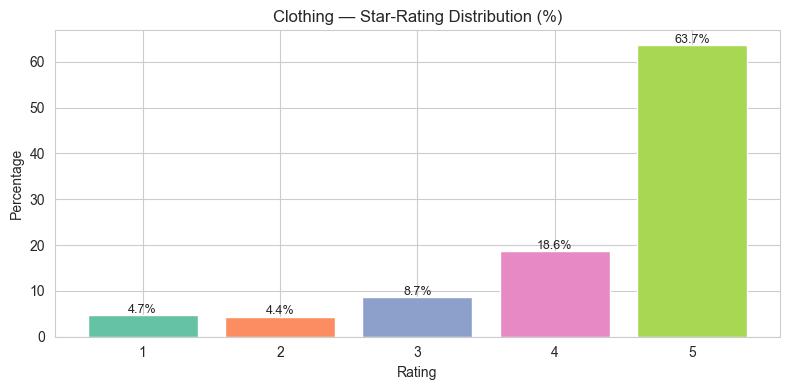

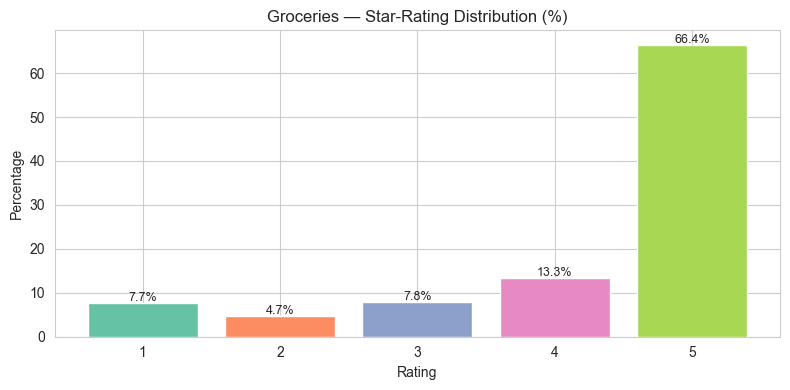

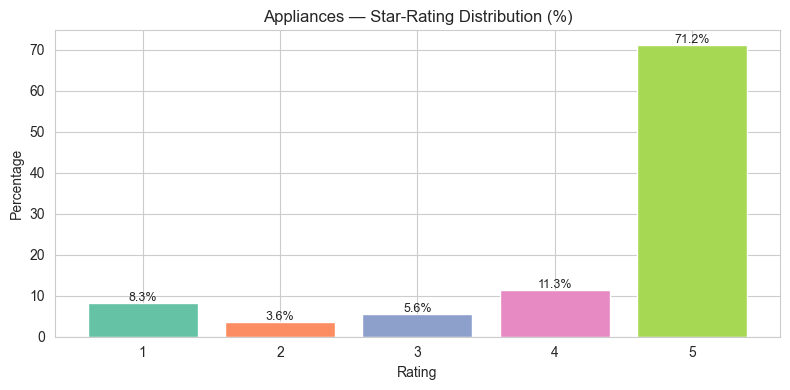

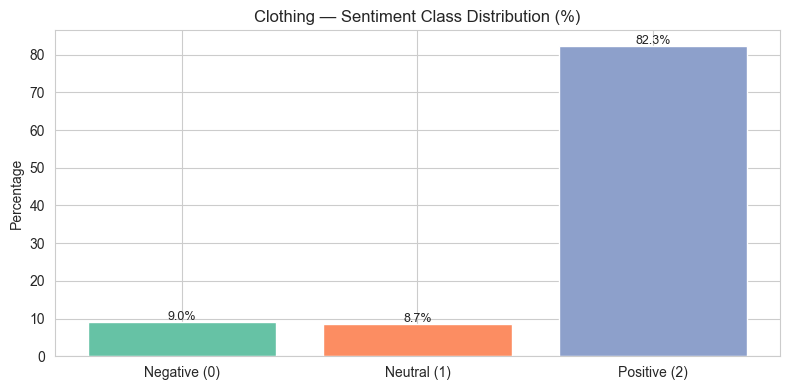

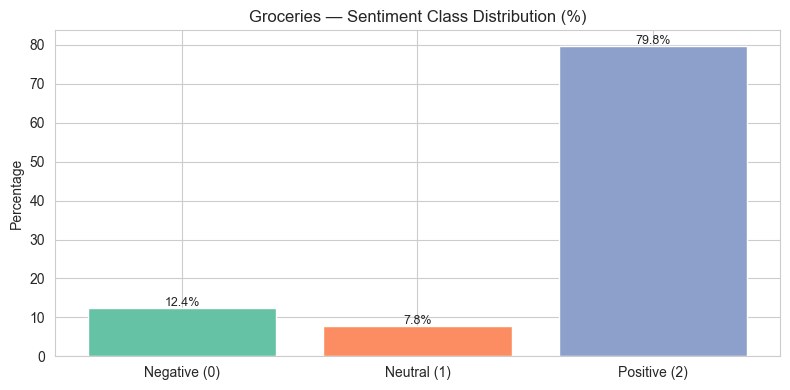

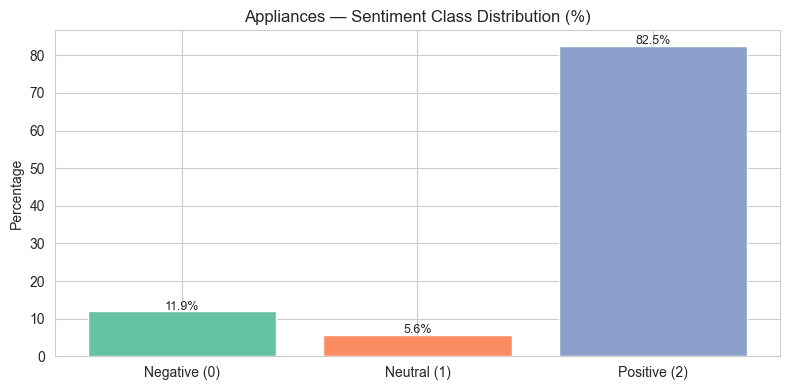

In [14]:
print('Plotting rating and class distributions...')
for domain_name, df in domain_dfs.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = df['rating'].value_counts().sort_index()
    pcts = (counts / counts.sum() * 100).round(2)
    ax.bar(pcts.index.astype(str), pcts.values, color=sns.color_palette('Set2', len(pcts)))
    ax.set_title(f'{domain_name} — Star-Rating Distribution (%)')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Percentage')
    for i, v in enumerate(pcts.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

for domain_name, df in domain_dfs.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    counts = df['label'].value_counts().sort_index()
    pcts = (counts / counts.sum() * 100).round(2)
    labels = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
    ax.bar(labels, pcts.values, color=sns.color_palette('Set2', len(pcts)))
    ax.set_title(f'{domain_name} — Sentiment Class Distribution (%)')
    ax.set_ylabel('Percentage')
    for i, v in enumerate(pcts.values):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

## 8. Define 6 Base Models

In [15]:
def get_base_model_builders():
    return OrderedDict([
        ('LR', lambda: LogisticRegression(max_iter=2000, n_jobs=-1, class_weight='balanced', random_state=RANDOM_STATE)),
        ('DT', lambda: DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
        ('RF', lambda: RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)),
        ('ET', lambda: ExtraTreesClassifier(n_estimators=300, class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE)),
        ('XGB', lambda: xgb.XGBClassifier(
            objective='multi:softprob', num_class=3, n_estimators=300,
            eval_metric='mlogloss', random_state=RANDOM_STATE,
            n_jobs=-1, tree_method='hist', verbosity=0)),
        ('LGBM', lambda: lgb.LGBMClassifier(
            objective='multiclass', num_class=3, n_estimators=300,
            random_state=RANDOM_STATE, class_weight='balanced',
            n_jobs=-1, verbose=-1)),
    ])

MODEL_NAMES = list(get_base_model_builders().keys())
print('Models:', MODEL_NAMES)


Models: ['LR', 'DT', 'RF', 'ET', 'XGB', 'LGBM']


## 9. G-Mean Helper

In [16]:
def geometric_mean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    recalls = []
    for i in range(cm.shape[0]):
        total = cm[i].sum()
        recalls.append(cm[i, i] / total if total > 0 else 0.0)
    return float(np.prod(recalls) ** (1.0 / len(recalls)))

print('G-Mean helper function defined.')

G-Mean helper function defined.


## 10. Train and Evaluate Base Models

In [17]:
# Storage dictionaries
all_results = {}      # {domain: {model_name: dict of metrics}}
all_models = {}       # {domain: {model_name: fitted model}}
all_splits = {}       # {domain: (X_train, X_test, y_train, y_test)}
all_vectorizers = {}  # {domain: fitted TfidfVectorizer}
all_preds = {}        # {domain: {model_name: y_pred}}

for domain_name, df in domain_dfs.items():
    print('\n' + '=' * 80)
    print(f'Training models for: {domain_name}')
    print('=' * 80)

    X_texts = df['clean_text'].values
    y = df['label'].values

    # TF-IDF vectorization
    tfidf = TfidfVectorizer(max_features=50_000, sublinear_tf=True, ngram_range=(1, 2))
    X = tfidf.fit_transform(X_texts)
    all_vectorizers[domain_name] = tfidf

    # Train/test split (80/20, stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    all_splits[domain_name] = (X_train, X_test, y_train, y_test)

    domain_results = {}
    domain_models = {}
    domain_preds = {}

    builders = get_base_model_builders()
    for model_name, builder_fn in builders.items():
        print(f'  Training {model_name}...')
        model = builder_fn()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        wf1 = f1_score(y_test, y_pred, average='weighted') * 100
        mcc = matthews_corrcoef(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)
        gmean = geometric_mean_score(y_test, y_pred)
        bacc = balanced_accuracy_score(y_test, y_pred) * 100

        domain_results[model_name] = {
            'Weighted F1-score': round(wf1, 3),
            'MCC': round(mcc, 4),
            'Cohen Kappa': round(kappa, 4),
            'G-Mean': round(gmean, 4),
            'Balanced Accuracy': round(bacc, 3),
        }
        domain_models[model_name] = model
        domain_preds[model_name] = y_pred
        print(f'    Weighted F1 = {wf1:.2f}%, MCC = {mcc:.4f}')

    all_results[domain_name] = domain_results
    all_models[domain_name] = domain_models
    all_preds[domain_name] = domain_preds


Training models for: Clothing
  Training LR...
    Weighted F1 = 84.38%, MCC = 0.5264
  Training DT...
    Weighted F1 = 77.71%, MCC = 0.3168
  Training RF...
    Weighted F1 = 79.77%, MCC = 0.3504
  Training ET...
    Weighted F1 = 79.60%, MCC = 0.3398
  Training XGB...
    Weighted F1 = 84.84%, MCC = 0.5106
  Training LGBM...
    Weighted F1 = 83.79%, MCC = 0.5044

Training models for: Groceries
  Training LR...
    Weighted F1 = 83.83%, MCC = 0.5488
  Training DT...
    Weighted F1 = 76.30%, MCC = 0.3338
  Training RF...
    Weighted F1 = 79.57%, MCC = 0.4250
  Training ET...
    Weighted F1 = 80.02%, MCC = 0.4371
  Training XGB...
    Weighted F1 = 83.76%, MCC = 0.5369
  Training LGBM...
    Weighted F1 = 82.81%, MCC = 0.5233

Training models for: Appliances
  Training LR...
    Weighted F1 = 85.15%, MCC = 0.5428
  Training DT...
    Weighted F1 = 79.85%, MCC = 0.3618
  Training RF...
    Weighted F1 = 82.22%, MCC = 0.4253
  Training ET...
    Weighted F1 = 81.26%, MCC = 0.3812
  

In [18]:
#SAVE CHECKPOINT 
import pickle

training_checkpoint = 'training_checkpoint.pkl'
with open(training_checkpoint, 'wb') as f:
    pickle.dump({
        'all_results': all_results,
        'all_models': all_models,
        'all_splits': all_splits,
        'all_vectorizers': all_vectorizers,
        'all_preds': all_preds,
    }, f)
print(f'Training checkpoint saved to {training_checkpoint}')


Training checkpoint saved to training_checkpoint.pkl


In [19]:
#lOAD CHECKPOINT
import pickle

training_checkpoint = 'training_checkpoint.pkl'
with open(training_checkpoint, 'rb') as f:
    data = pickle.load(f)
all_results = data['all_results']
all_models = data['all_models']
all_splits = data['all_splits']
all_vectorizers = data['all_vectorizers']
all_preds = data['all_preds']
print(f'Training checkpoint loaded from {training_checkpoint}')
for domain_name in all_results:
    print(f"  {domain_name}: {len(all_models[domain_name])} models trained")


Training checkpoint loaded from training_checkpoint.pkl
  Clothing: 6 models trained
  Groceries: 6 models trained
  Appliances: 6 models trained


## 11. Base Model Results Tables 

In [20]:
from IPython.display import display

final_tables = {}
for domain_name in domain_dfs:
    rows = []
    for model_name, metrics in all_results[domain_name].items():
        row = {'Model': model_name}
        row.update(metrics)
        rows.append(row)
    table = pd.DataFrame(rows).sort_values('Weighted F1-score', ascending=False).reset_index(drop=True)
    final_tables[domain_name] = table
    print(f'\n--- {domain_name} ---')
    display(table)


--- Clothing ---


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,XGB,84.845,0.5106,0.4906,0.4480,56.257
1,LR,84.384,0.5264,0.5171,0.6461,67.335
2,LGBM,83.795,0.5044,0.4971,0.6152,64.861
3,RF,79.770,0.3504,0.2684,0.1430,44.054
4,ET,79.599,0.3398,0.2562,0.1601,43.510
5,DT,77.708,0.3168,0.3131,0.4528,52.228



--- Groceries ---


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,LR,83.834,0.5488,0.5425,0.6362,66.656
1,XGB,83.759,0.5369,0.5169,0.4129,56.092
2,LGBM,82.813,0.5233,0.5161,0.6157,65.015
3,ET,80.018,0.4371,0.3688,0.2194,47.209
4,RF,79.567,0.4250,0.3530,0.1936,46.452
5,DT,76.303,0.3338,0.3314,0.4533,51.919



--- Appliances ---


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,XGB,85.507,0.5346,0.5112,0.3113,53.518
1,LR,85.148,0.5428,0.5325,0.6148,65.909
2,LGBM,84.541,0.5233,0.5141,0.5843,64.115
3,RF,82.221,0.4253,0.3452,0.1628,45.077
4,ET,81.262,0.3812,0.3011,0.1467,43.292
5,DT,79.850,0.3618,0.3587,0.4464,52.861


## 12. Stacking Classifier (Single Stack, LR Meta-Learner)

In [27]:
from sklearn.model_selection import cross_val_predict

stack_results = {}
stack_models = {}
stack_preds = {}

for domain_name in domain_dfs:
    print(f'\nBuilding stacking for {domain_name}...')
    X_train, X_test, y_train, y_test = all_splits[domain_name]

    # Get meta-features from already-trained base models (no retraining!)
    train_meta = np.column_stack([
        all_models[domain_name][name].predict_proba(X_train)
        for name in MODEL_NAMES
    ])
    test_meta = np.column_stack([
        all_models[domain_name][name].predict_proba(X_test)
        for name in MODEL_NAMES
    ])

    # Train only the meta-learner (very fast)
    meta_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    meta_lr.fit(train_meta, y_train)
    y_pred_stack = meta_lr.predict(test_meta)

    wf1 = f1_score(y_test, y_pred_stack, average='weighted') * 100
    mcc = matthews_corrcoef(y_test, y_pred_stack)
    kappa = cohen_kappa_score(y_test, y_pred_stack)
    gmean = geometric_mean_score(y_test, y_pred_stack)
    bacc = balanced_accuracy_score(y_test, y_pred_stack) * 100

    stack_results[domain_name] = {'Weighted F1-score': round(wf1, 3), 'MCC': round(mcc, 4), 'Cohen Kappa': round(kappa, 4), 'G-Mean': round(gmean, 4), 'Balanced Accuracy': round(bacc, 3)}
    stack_preds[domain_name] = y_pred_stack

    # Store a simple object so SHAP section can access meta_lr and meta features
    class SimpleStack:
        pass
    ss = SimpleStack()
    ss.final_estimator_ = meta_lr
    ss.transform = lambda X, dn=domain_name: np.column_stack([
        all_models[dn][name].predict_proba(X) for name in MODEL_NAMES
    ])
    stack_models[domain_name] = ss

    print(f'  Stack Weighted F1 = {wf1:.2f}%, MCC = {mcc:.4f}')

# Update tables
for domain_name in domain_dfs:
    stack_row = {'Model': 'Stack'}
    stack_row.update(stack_results[domain_name])
    final_tables[domain_name] = pd.concat(
        [final_tables[domain_name], pd.DataFrame([stack_row])], ignore_index=True
    )
    print(f'\n{domain_name}:')
    display(final_tables[domain_name])

print('\nAll stacking DONE.')



Building stacking for Clothing...
  Stack Weighted F1 = 81.34%, MCC = 0.4051

Building stacking for Groceries...
  Stack Weighted F1 = 80.85%, MCC = 0.4456

Building stacking for Appliances...
  Stack Weighted F1 = 83.52%, MCC = 0.4654

Clothing:


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,XGB,84.845,0.5106,0.4906,0.4480,56.257
1,LR,84.384,0.5264,0.5171,0.6461,67.335
2,LGBM,83.795,0.5044,0.4971,0.6152,64.861
3,RF,79.770,0.3504,0.2684,0.1430,44.054
4,ET,79.599,0.3398,0.2562,0.1601,43.510
5,DT,77.708,0.3168,0.3131,0.4528,52.228
6,Stack,81.343,0.4051,0.3433,0.2539,47.357



Groceries:


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,LR,83.834,0.5488,0.5425,0.6362,66.656
1,XGB,83.759,0.5369,0.5169,0.4129,56.092
2,LGBM,82.813,0.5233,0.5161,0.6157,65.015
3,ET,80.018,0.4371,0.3688,0.2194,47.209
4,RF,79.567,0.4250,0.3530,0.1936,46.452
5,DT,76.303,0.3338,0.3314,0.4533,51.919
6,Stack,80.845,0.4456,0.4053,0.3020,49.076



Appliances:


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,XGB,85.507,0.5346,0.5112,0.3113,53.518
1,LR,85.148,0.5428,0.5325,0.6148,65.909
2,LGBM,84.541,0.5233,0.5141,0.5843,64.115
3,RF,82.221,0.4253,0.3452,0.1628,45.077
4,ET,81.262,0.3812,0.3011,0.1467,43.292
5,DT,79.850,0.3618,0.3587,0.4464,52.861
6,Stack,83.520,0.4654,0.4187,0.2161,48.290



All stacking DONE.


In [30]:
#CHECK POINT SAVE
import pickle
with open('checkpoint_stacking.pkl', 'wb') as f:
    pickle.dump({
        'stack_results': stack_results,
        'stack_preds': stack_preds,
        'final_tables': final_tables
    }, f)
print('Checkpoint saved: stacking')



Checkpoint saved: stacking


In [32]:
#CHECKPOINT LOAD + RECONSTRUCT FOR SHAP
import pickle
with open('checkpoint_stacking.pkl', 'rb') as f:
    data = pickle.load(f)
stack_results = data['stack_results']
stack_preds = data['stack_preds']
final_tables = data['final_tables']

# Reconstruct stack_models for SHAP
stack_models = {}
for domain_name in domain_dfs:
    X_train, X_test, y_train, y_test = all_splits[domain_name]
    train_meta = np.column_stack([all_models[domain_name][name].predict_proba(X_train) for name in MODEL_NAMES])
    meta_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    meta_lr.fit(train_meta, y_train)
    class SimpleStack:
        pass
    ss = SimpleStack()
    ss.final_estimator_ = meta_lr
    ss.transform = lambda X, dn=domain_name: np.column_stack([all_models[dn][name].predict_proba(X) for name in MODEL_NAMES])
    stack_models[domain_name] = ss

print('Checkpoint loaded: stacking (with reconstructed stack_models)')


Checkpoint loaded: stacking (with reconstructed stack_models)


## 13. Stacking Confusion Matrices

Plotting stacking confusion matrices...


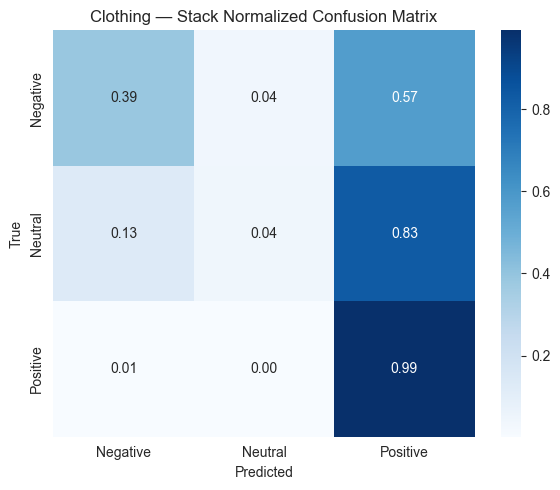

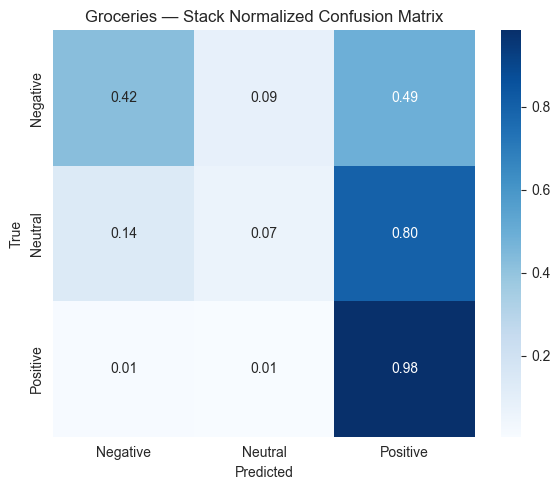

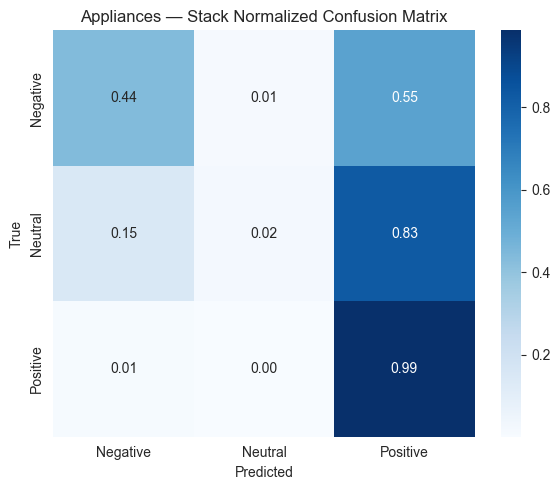

In [33]:
print('Plotting stacking confusion matrices...')
def plot_normalized_cm(y_true, y_pred, domain_name, model_tag='Stack'):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    labels = ['Negative', 'Neutral', 'Positive']
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{domain_name} — {model_tag} Normalized Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

for domain_name in domain_dfs:
    _, _, _, y_test = all_splits[domain_name]
    plot_normalized_cm(y_test, stack_preds[domain_name], domain_name)

## 14. SHAP Model-Level Analysis 
SHAP on the stacking meta-learner's features (each feature = a base model's
predicted probability for one class). Adapted for 6 base models.


--- SHAP Model-Level: Clothing ---


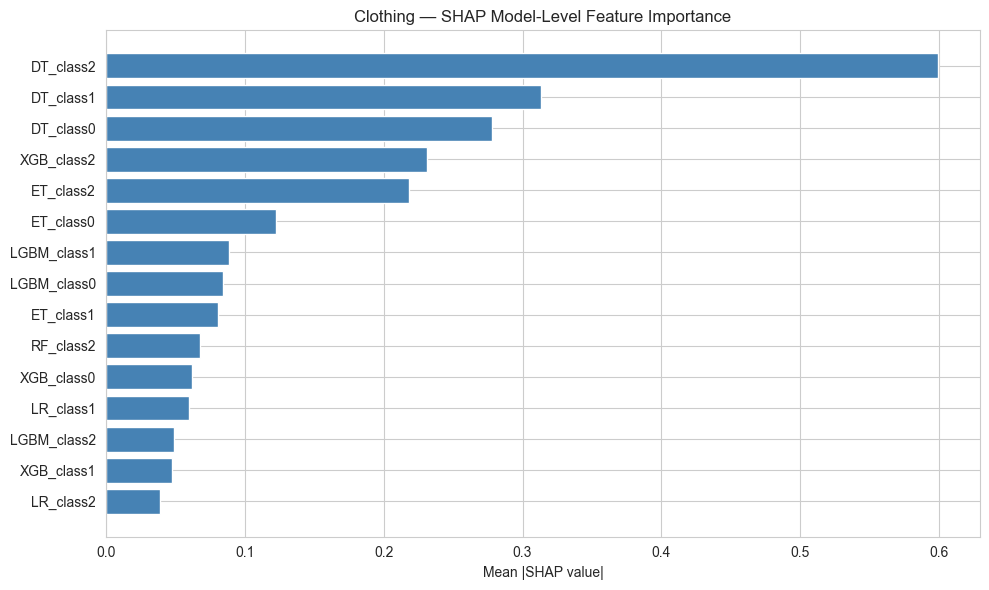

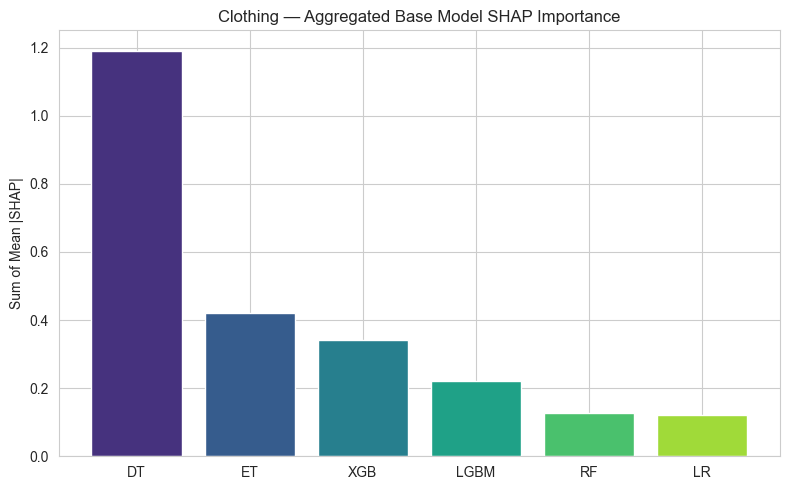


--- SHAP Model-Level: Groceries ---


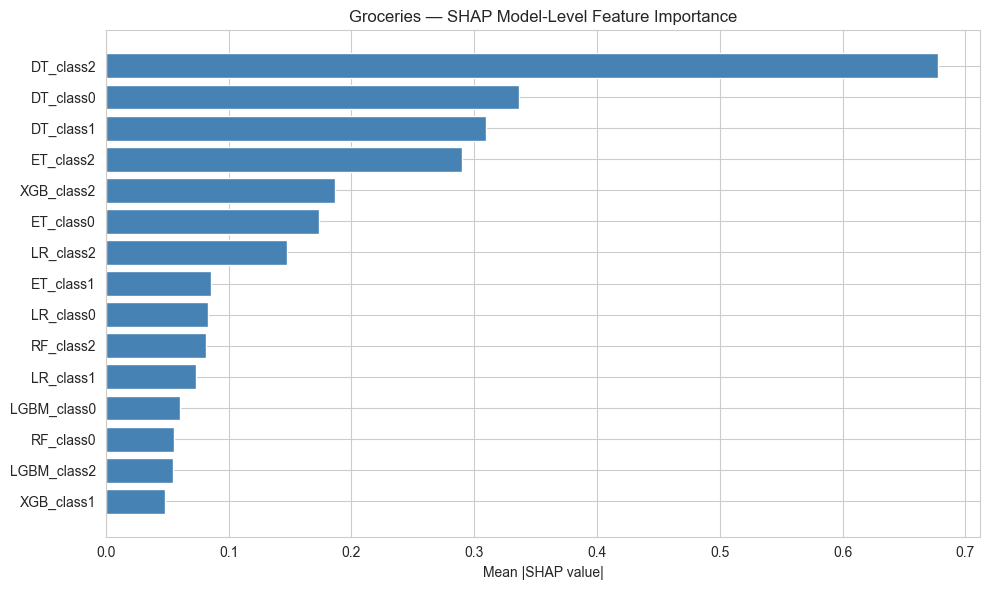

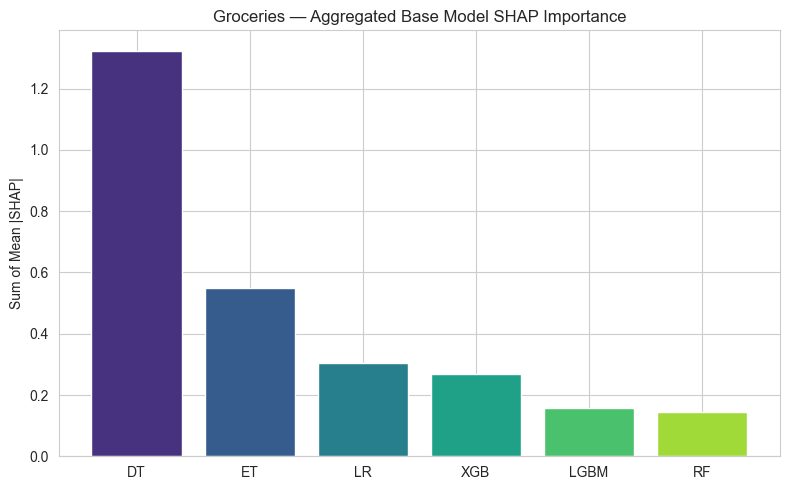


--- SHAP Model-Level: Appliances ---


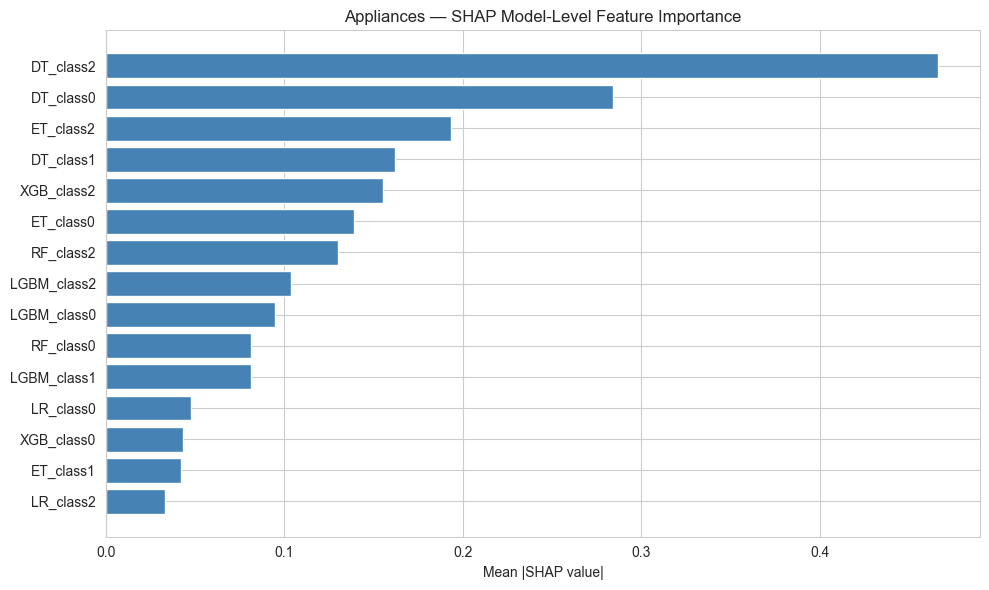

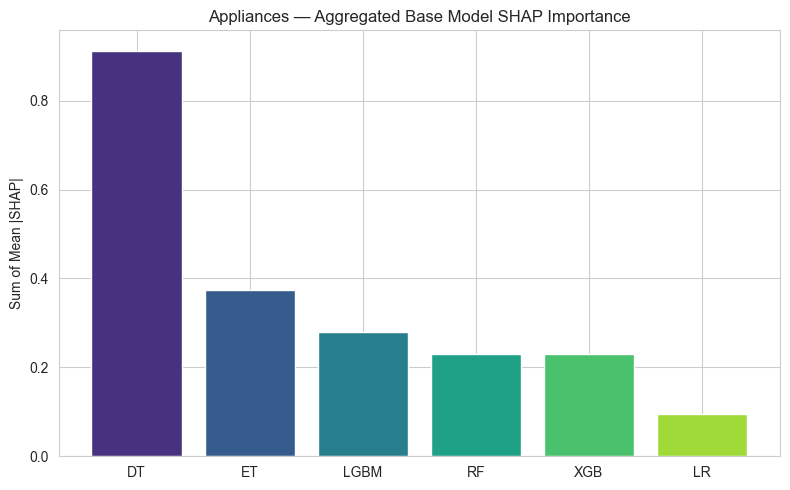

In [35]:
for domain_name in domain_dfs:
    print(f'\n--- SHAP Model-Level: {domain_name} ---')
    X_train, X_test, y_train, y_test = all_splits[domain_name]
    stack = stack_models[domain_name]

    # Get stacking meta-features
    meta_features_test = stack.transform(X_test)
    n_classes = len(np.unique(y_test))
    feature_names = []
    for name in MODEL_NAMES:
        for c in range(n_classes):
            feature_names.append(f'{name}_class{c}')

    meta_df = pd.DataFrame(meta_features_test, columns=feature_names[:meta_features_test.shape[1]])

    # SHAP on the meta-learner
    meta_lr = stack.final_estimator_
    explainer = shap.LinearExplainer(meta_lr, meta_df)
    shap_values = explainer.shap_values(meta_df)

    # Handle different SHAP output shapes
    if isinstance(shap_values, list):
        avg_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        avg_shap = np.mean(np.abs(shap_values), axis=2)
    else:
        avg_shap = np.abs(shap_values)

    mean_importance = avg_shap.mean(axis=0).flatten()
    importance_df = pd.DataFrame({
        'Feature': meta_df.columns[:len(mean_importance)],
        'Mean |SHAP|': mean_importance
    }).sort_values('Mean |SHAP|', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['Feature'], importance_df['Mean |SHAP|'], color='steelblue')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'{domain_name} — SHAP Model-Level Feature Importance')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # Fig. 10 style — Aggregated base model importance
    model_importance = {}
    for name in MODEL_NAMES:
        cols = [c for c in meta_df.columns if c.startswith(name + '_')]
        col_indices = [list(meta_df.columns).index(c) for c in cols]
        model_importance[name] = mean_importance[col_indices].sum()

    sorted_models = sorted(model_importance.items(), key=lambda x: x[1], reverse=True)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([m[0] for m in sorted_models], [m[1] for m in sorted_models],
           color=sns.color_palette('viridis', len(sorted_models)))
    ax.set_title(f'{domain_name} — Aggregated Base Model SHAP Importance')
    ax.set_ylabel('Sum of Mean |SHAP|')
    plt.tight_layout()
    plt.show()


## Fig. 11 — Per-class base model SHAP importance

Plotting per-class base model SHAP importance...


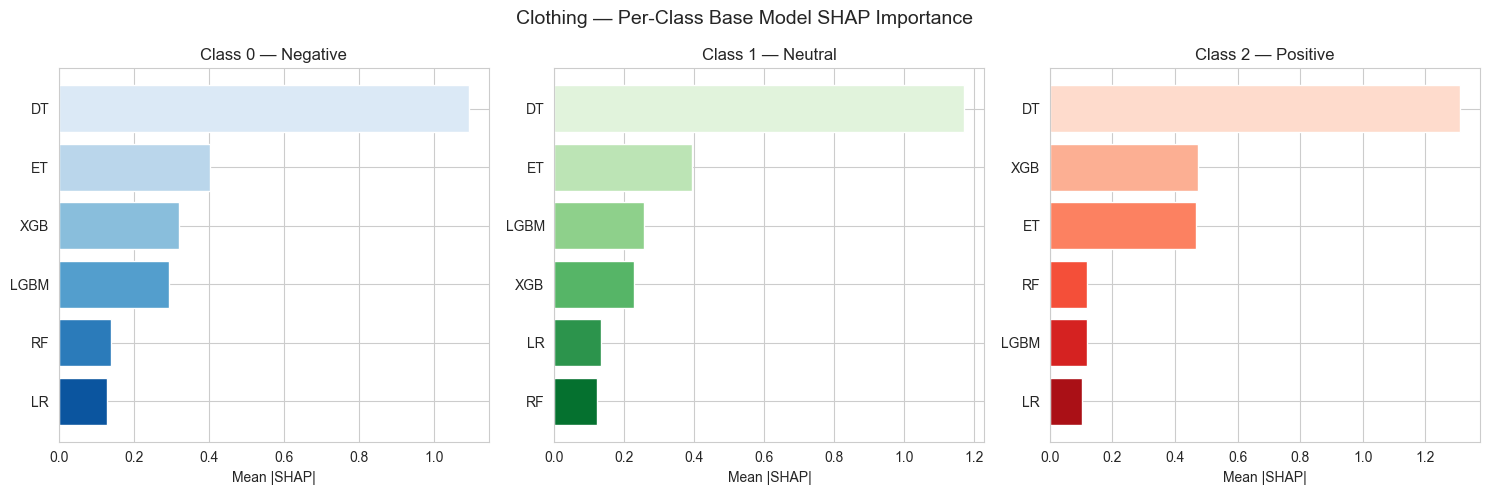

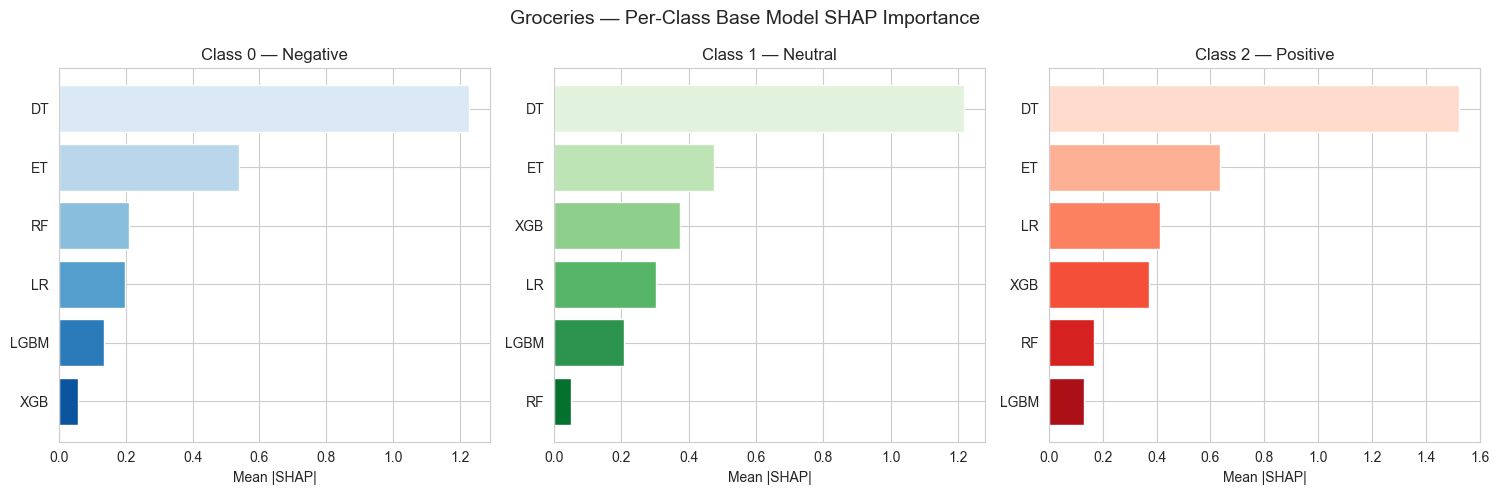

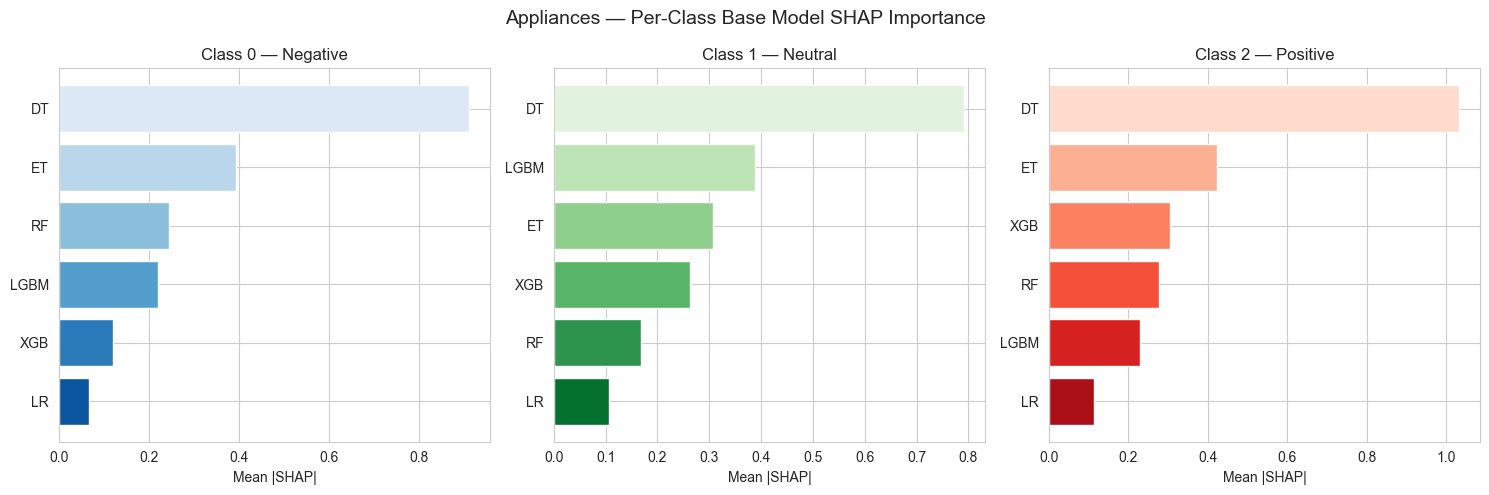

In [45]:
print('Plotting per-class base model SHAP importance...')
for domain_name in domain_dfs:
    X_train, X_test, y_train, y_test = all_splits[domain_name]
    stack = stack_models[domain_name]

    meta_features_test = stack.transform(X_test)
    n_classes = len(np.unique(y_test))
    feature_names_meta = []
    for name in MODEL_NAMES:
        for c in range(n_classes):
            feature_names_meta.append(f'{name}_class{c}')

    meta_df = pd.DataFrame(meta_features_test, columns=feature_names_meta[:meta_features_test.shape[1]])
    meta_lr = stack.final_estimator_
    explainer = shap.LinearExplainer(meta_lr, meta_df)
    shap_values = explainer.shap_values(meta_df)

    class_labels = ['Negative', 'Neutral', 'Positive']
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif isinstance(shap_values, list):
        shap_list = shap_values
    else:
        shap_list = [shap_values]

    fig, axes = plt.subplots(1, min(3, len(shap_list)), figsize=(5 * min(3, len(shap_list)), 5))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    colors = [sns.color_palette('Blues_r', len(MODEL_NAMES)),
              sns.color_palette('Greens_r', len(MODEL_NAMES)),
              sns.color_palette('Reds_r', len(MODEL_NAMES))]

    for cls_idx in range(min(3, len(shap_list))):
        sv = np.abs(shap_list[cls_idx])
        mean_imp = sv.mean(axis=0)
        model_imp = {}
        for name in MODEL_NAMES:
            cols = [i for i, c in enumerate(meta_df.columns) if c.startswith(name + '_')]
            model_imp[name] = mean_imp[cols].sum()
        sorted_m = sorted(model_imp.items(), key=lambda x: x[1], reverse=True)
        axes[cls_idx].barh([m[0] for m in sorted_m][::-1], [m[1] for m in sorted_m][::-1], color=colors[cls_idx])
        axes[cls_idx].set_title(f'Class {cls_idx} — {class_labels[cls_idx]}')
        axes[cls_idx].set_xlabel('Mean |SHAP|')

    fig.suptitle(f'{domain_name} — Per-Class Base Model SHAP Importance', fontsize=14)
    plt.tight_layout()
    plt.show()


## 15. SHAP Feature-Level Interpretation — LightGBM

Uses TreeExplainer for fast SHAP on the LightGBM model.


--- SHAP Feature-Level (LGBM): Clothing ---


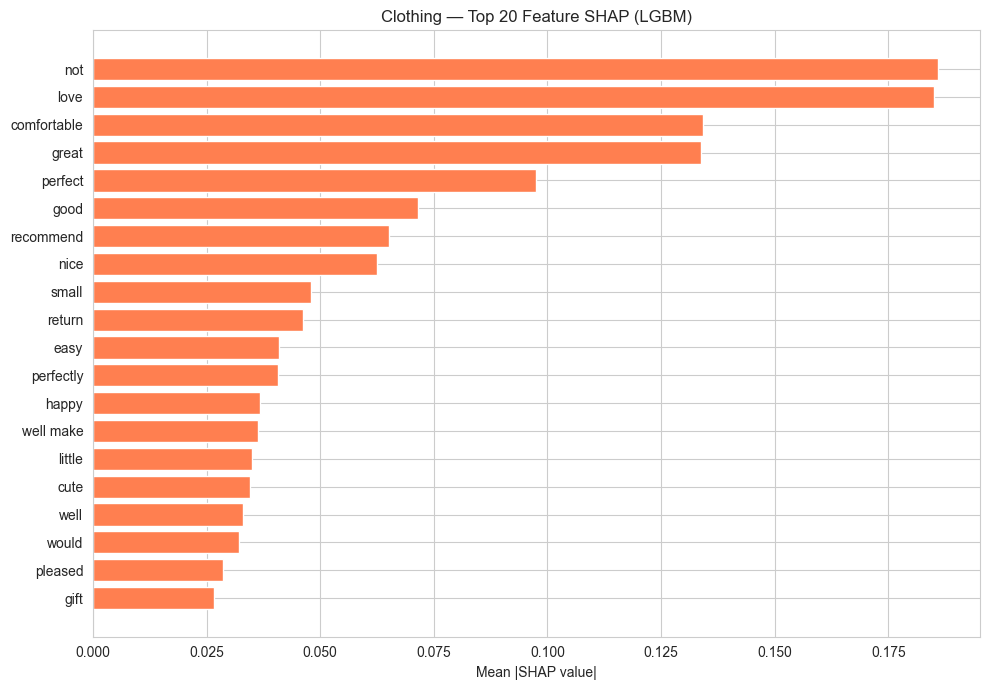

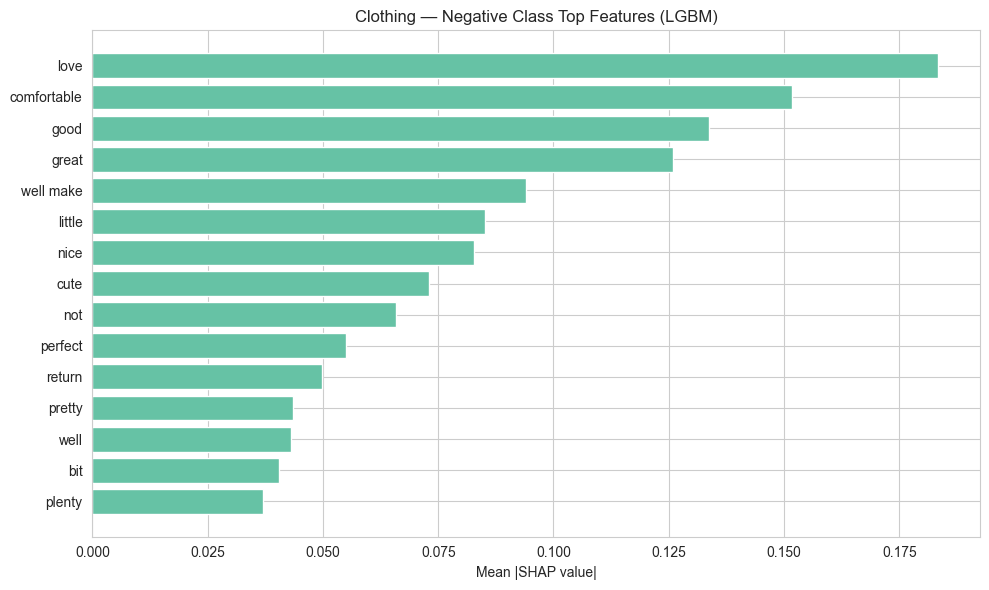

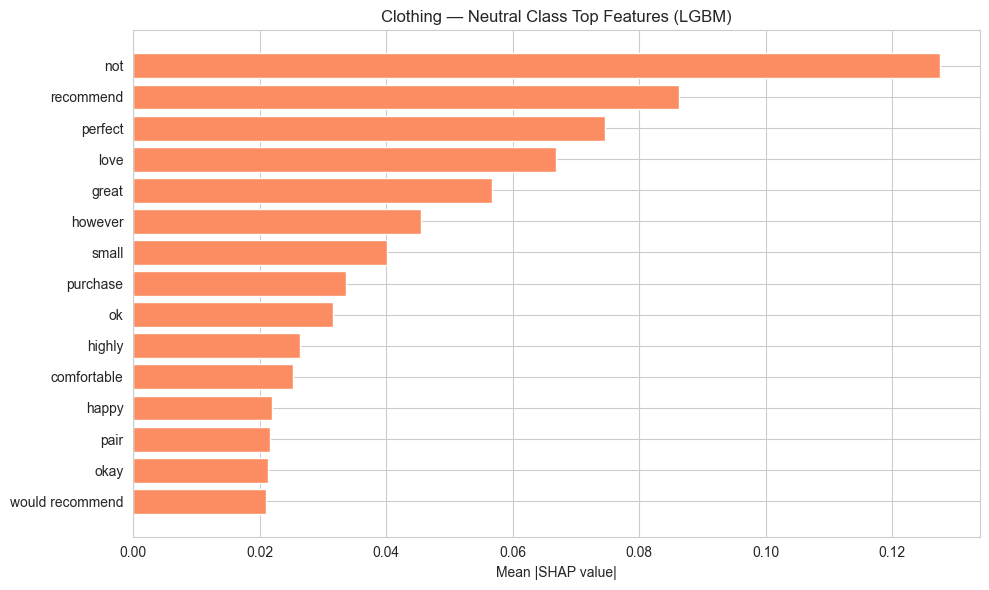

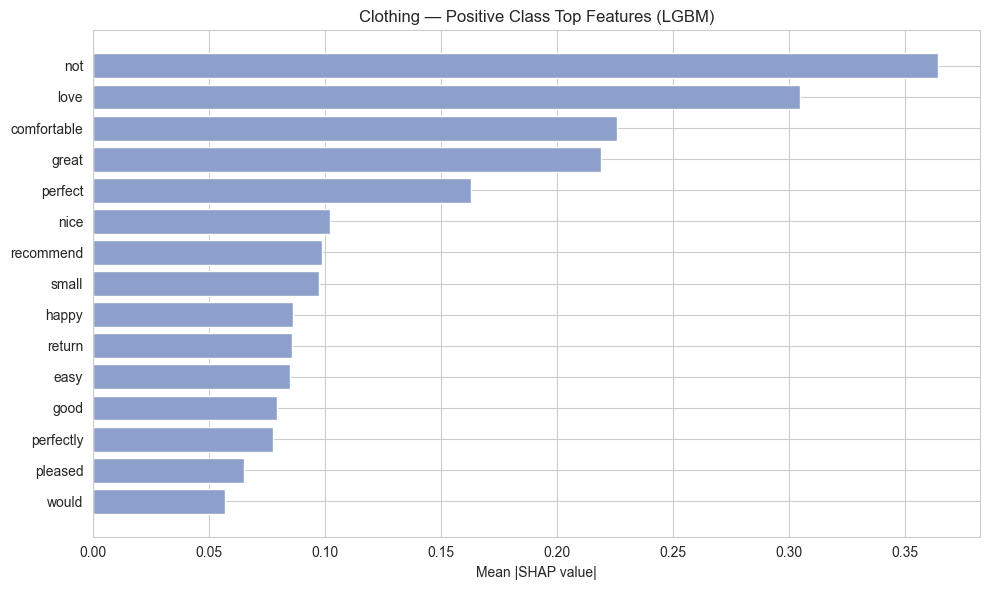

  Clothing SHAP feature-level DONE.

--- SHAP Feature-Level (LGBM): Groceries ---


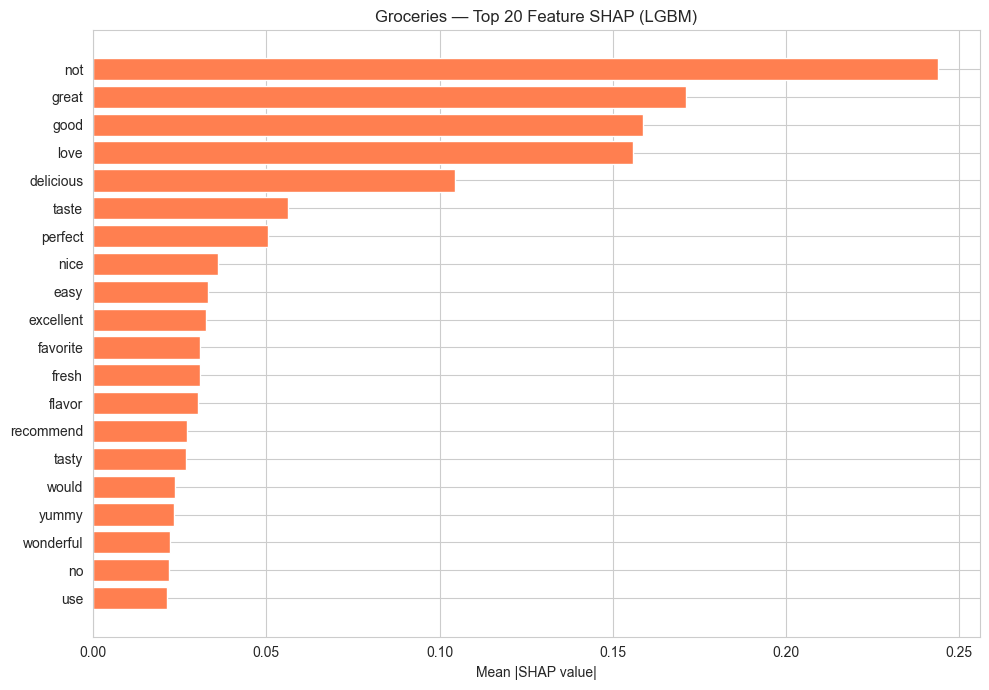

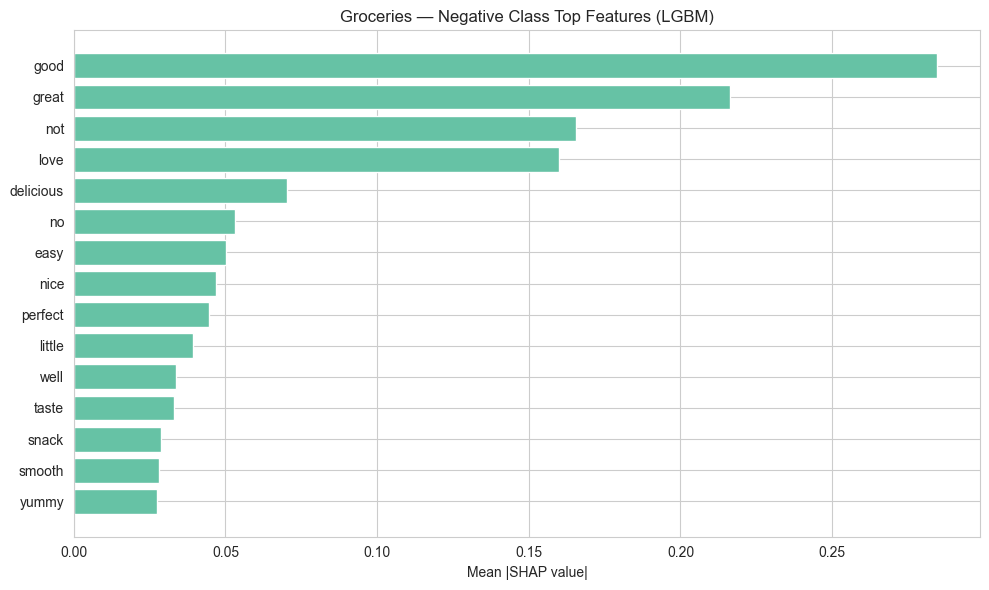

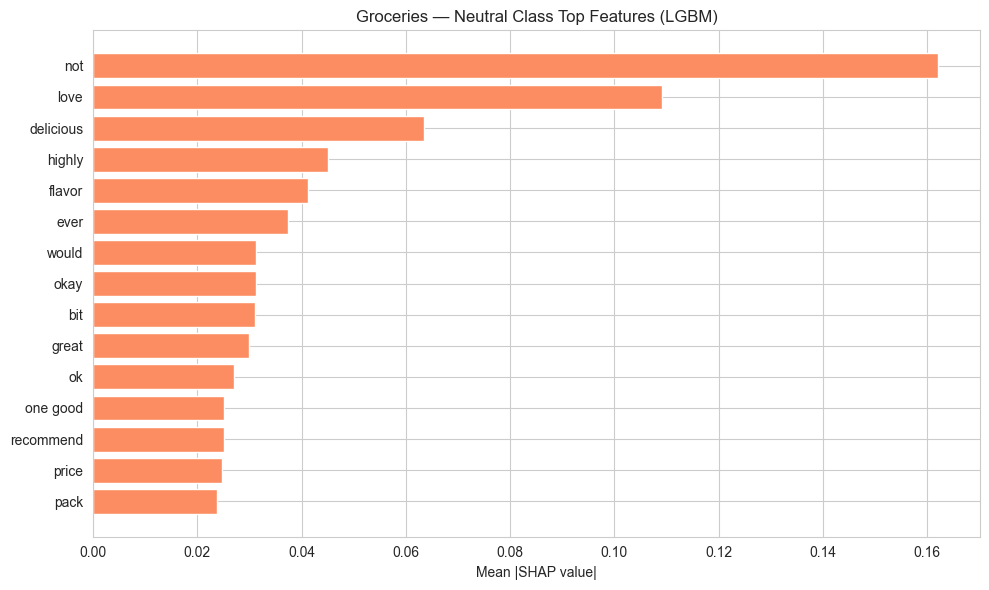

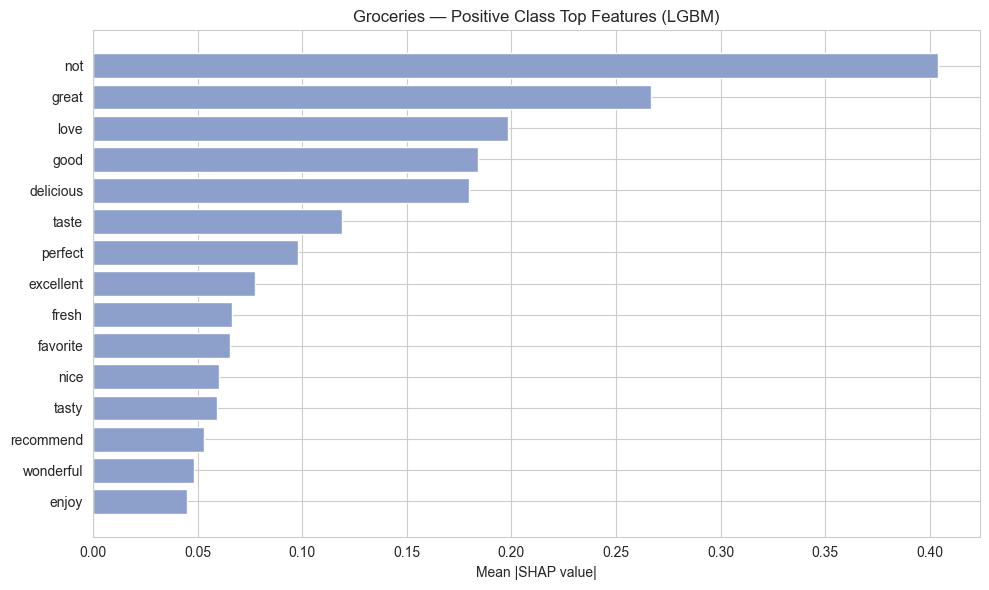

  Groceries SHAP feature-level DONE.

--- SHAP Feature-Level (LGBM): Appliances ---


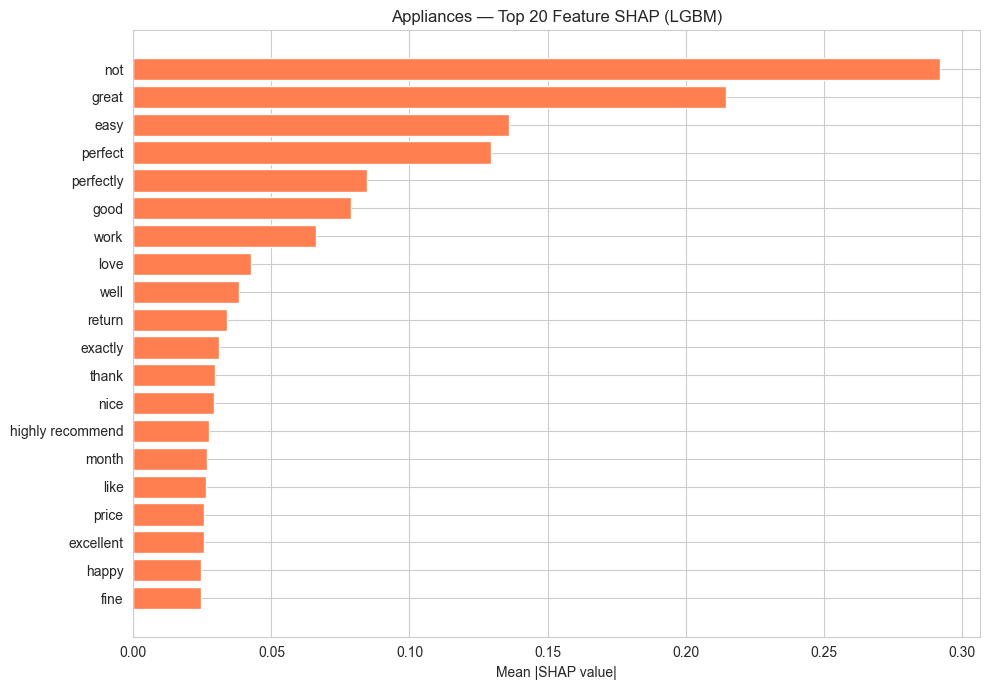

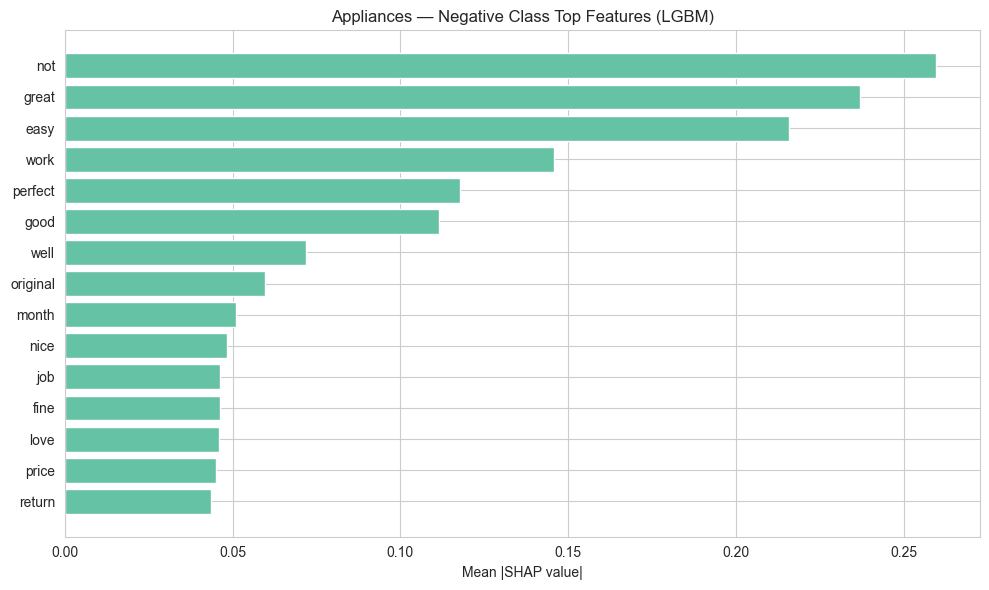

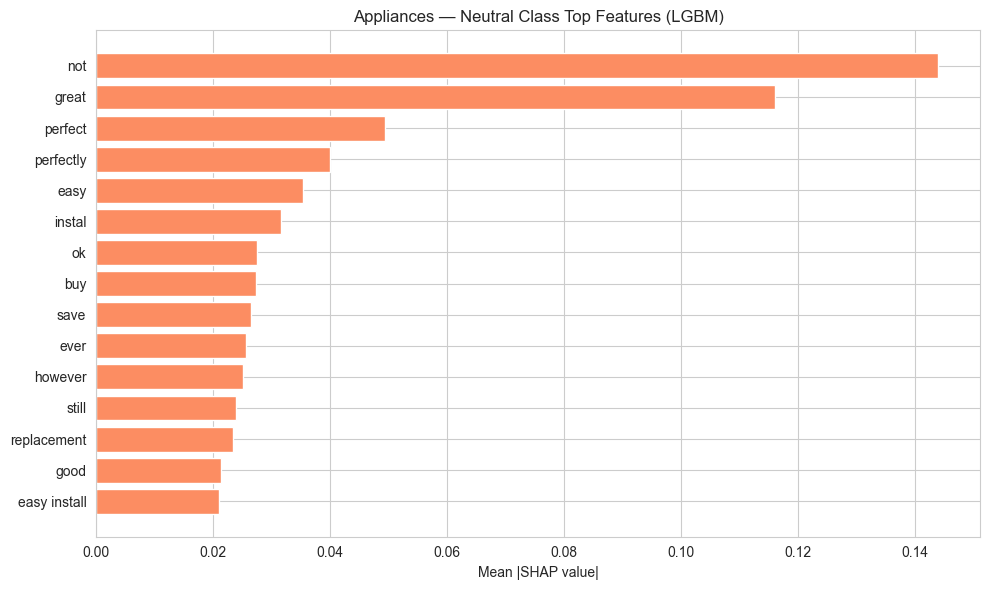

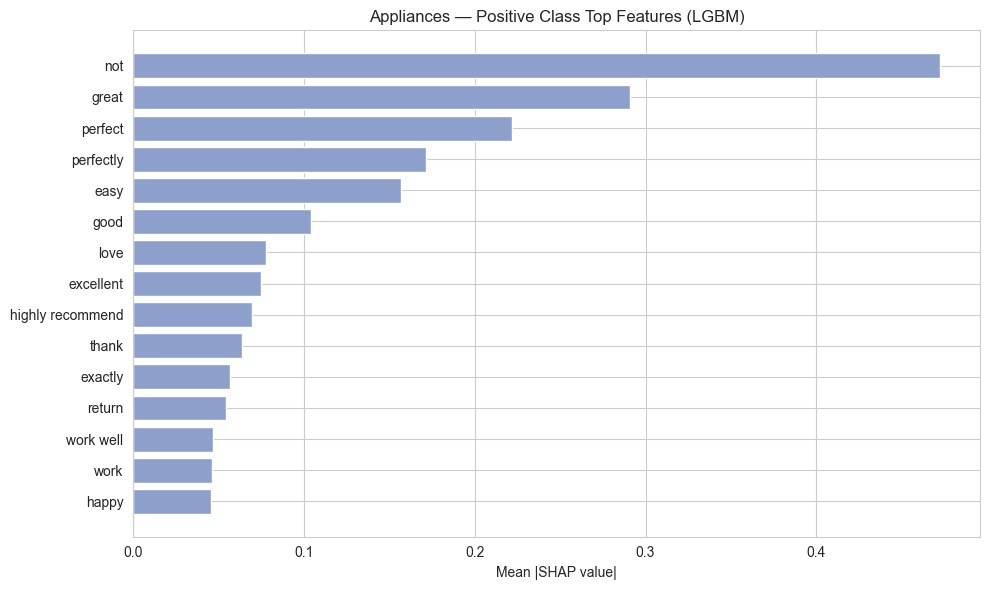

  Appliances SHAP feature-level DONE.


In [39]:
for domain_name in domain_dfs:
    print(f'\n--- SHAP Feature-Level (LGBM): {domain_name} ---')
    X_train, X_test, y_train, y_test = all_splits[domain_name]
    lgbm_model = all_models[domain_name]['LGBM']
    tfidf = all_vectorizers[domain_name]
    feature_names = tfidf.get_feature_names_out()
    n_features = len(feature_names)

    n_explain = min(300, X_test.shape[0])
    X_explain = X_test[:n_explain]
    if hasattr(X_explain, 'toarray'):
        X_explain_dense = X_explain.toarray().astype(np.float64)
    else:
        X_explain_dense = np.array(X_explain, dtype=np.float64)

    explainer = shap.TreeExplainer(lgbm_model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X_explain_dense)

    # Normalize shape: ensure we have a list of [class0, class1, class2]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif isinstance(shap_values, list):
        shap_list = shap_values
    else:
        shap_list = [shap_values]

    # Fig. 13 — Global feature importance (averaged across classes)
    avg_shap = np.mean([np.abs(sv[:, :n_features]) for sv in shap_list], axis=0)
    mean_feat_importance = avg_shap.mean(axis=0)
    top_k = 20
    top_indices = np.argsort(mean_feat_importance)[-top_k:][::-1]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(top_k), mean_feat_importance[top_indices][::-1], color='coral')
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(feature_names[top_indices][::-1])
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'{domain_name} — Top {top_k} Feature SHAP (LGBM)')
    plt.tight_layout()
    plt.show()

    # Fig. 14-16 — Per-class feature SHAP
    class_labels = ['Negative', 'Neutral', 'Positive']
    for cls_idx, cls_name in enumerate(class_labels):
        if cls_idx >= len(shap_list):
            break
        sv = np.abs(shap_list[cls_idx][:, :n_features])
        cls_importance = sv.mean(axis=0)
        cls_top = np.argsort(cls_importance)[-15:][::-1]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(range(15), cls_importance[cls_top][::-1],
                color=sns.color_palette('Set2')[cls_idx])
        ax.set_yticks(range(15))
        ax.set_yticklabels(feature_names[cls_top][::-1])
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title(f'{domain_name} — {cls_name} Class Top Features (LGBM)')
        plt.tight_layout()
        plt.show()

    print(f'  {domain_name} SHAP feature-level DONE.')


## Fig. 14-16 — Feature-level waterfall (LGBM, per class) 

Plotting feature-level waterfall plots (LGBM)...
Clothing — Negative Feature Waterfall (sample 0)


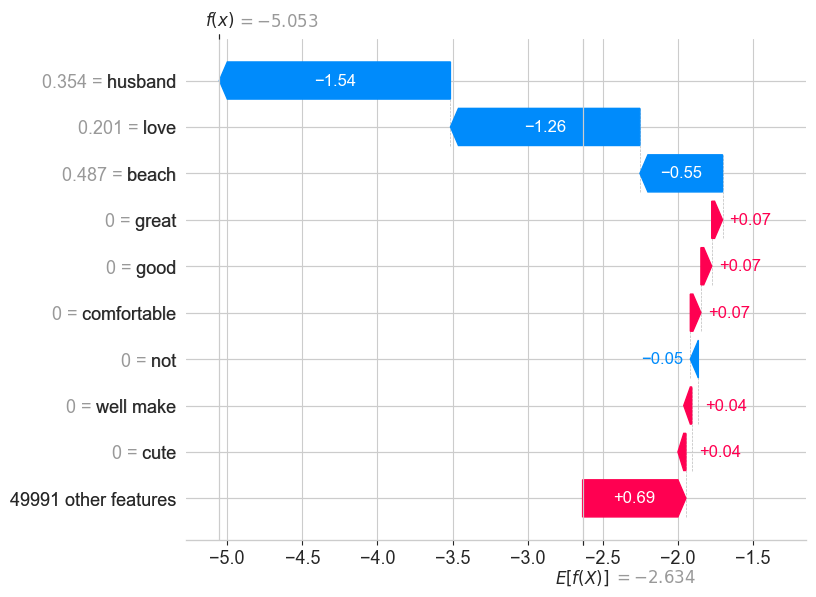

Clothing — Neutral Feature Waterfall (sample 0)


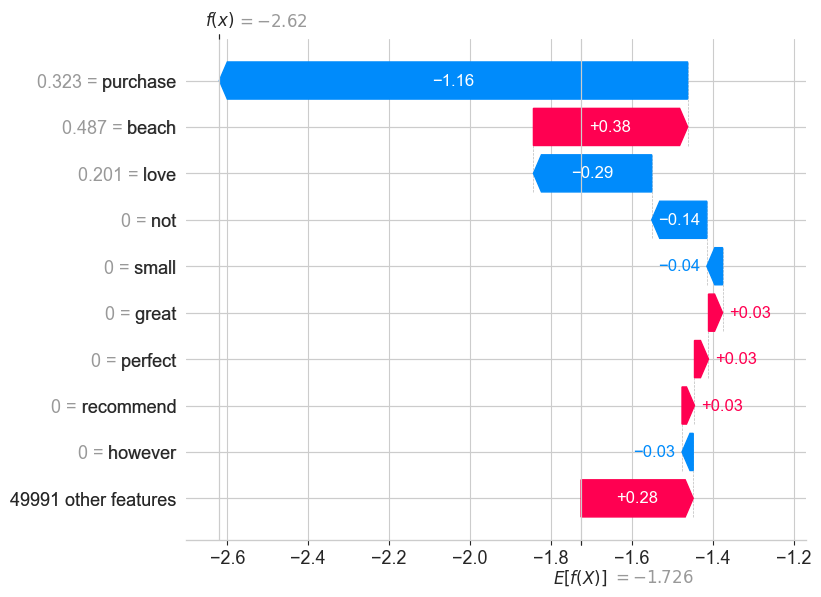

Clothing — Positive Feature Waterfall (sample 0)


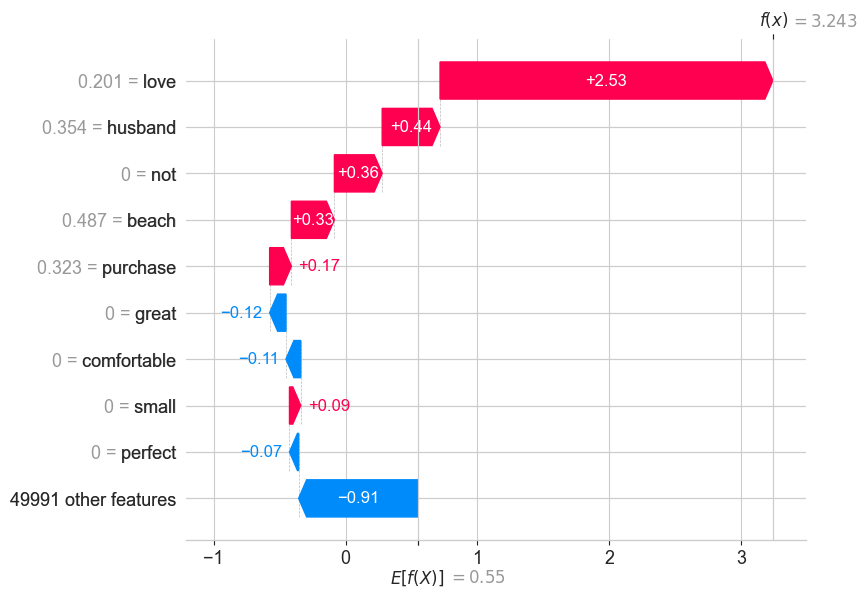

Groceries — Negative Feature Waterfall (sample 0)


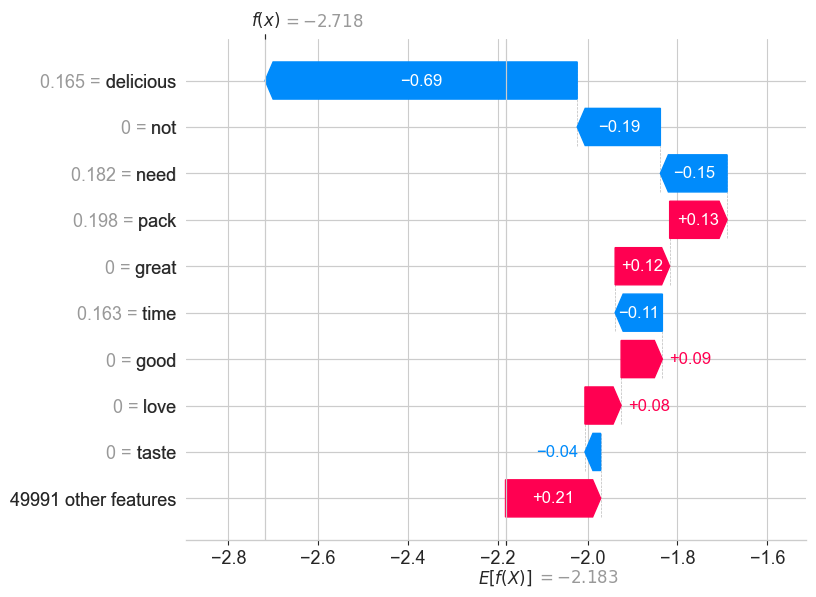

Groceries — Neutral Feature Waterfall (sample 0)


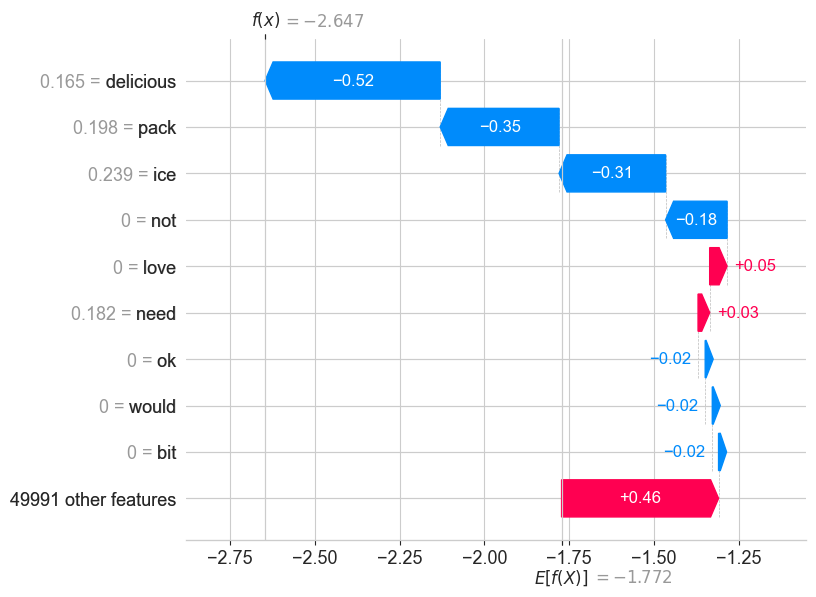

Groceries — Positive Feature Waterfall (sample 0)


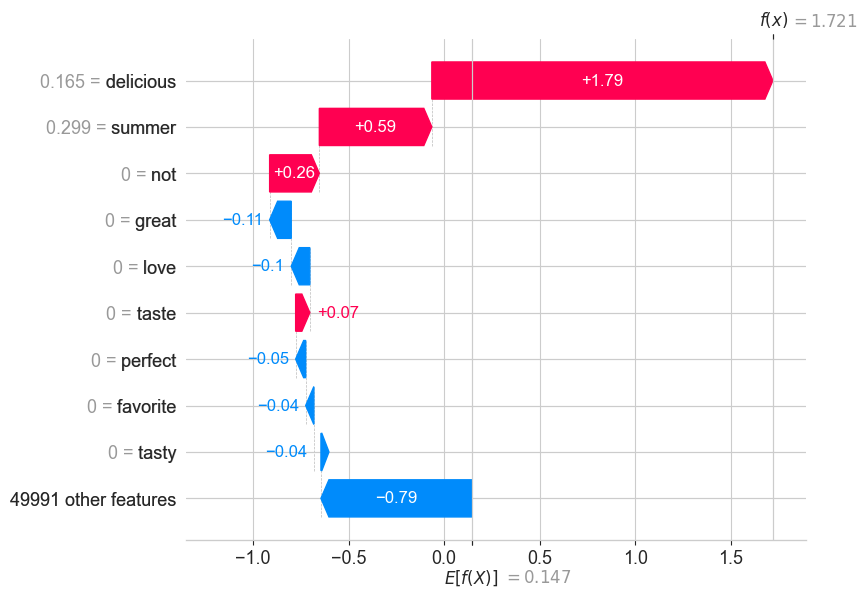

Appliances — Negative Feature Waterfall (sample 0)


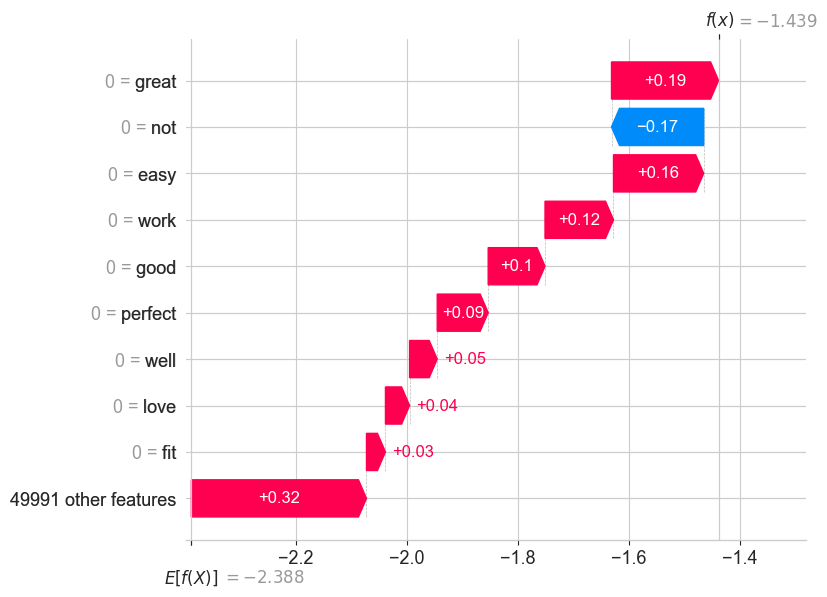

Appliances — Neutral Feature Waterfall (sample 0)


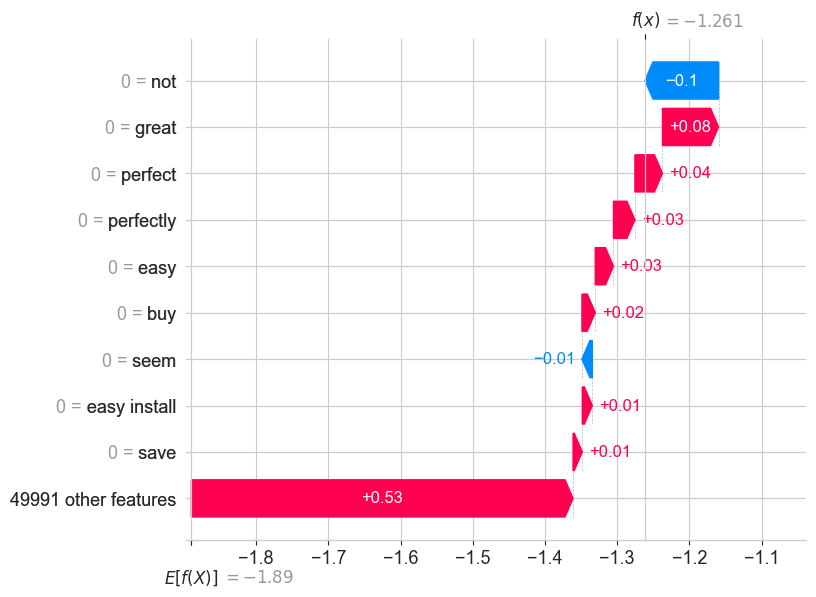

Appliances — Positive Feature Waterfall (sample 0)


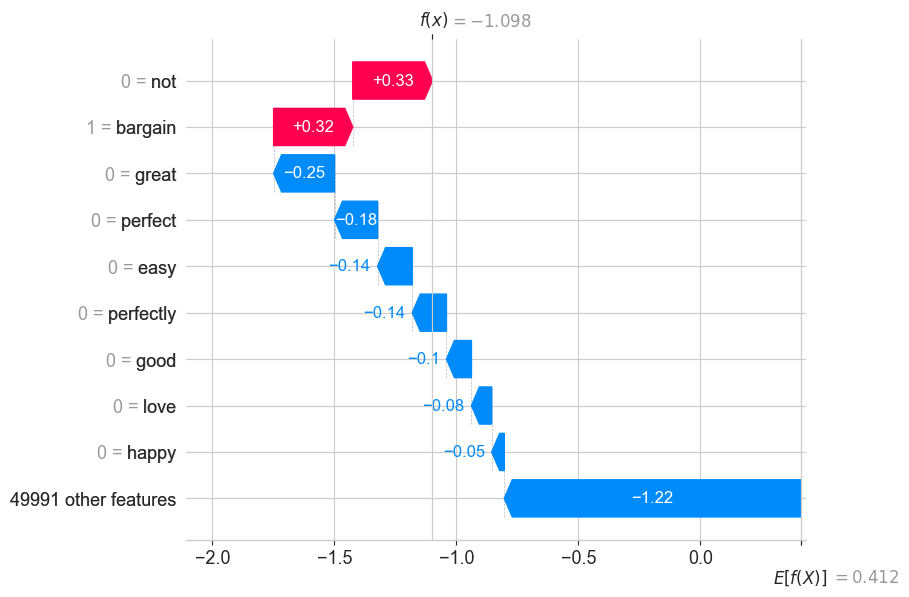

In [46]:
print('Plotting feature-level waterfall plots (LGBM)...')
for domain_name in domain_dfs:
    X_train, X_test, y_train, y_test = all_splits[domain_name]
    lgbm_model = all_models[domain_name]['LGBM']
    tfidf = all_vectorizers[domain_name]
    feature_names = tfidf.get_feature_names_out()

    sample_idx = 0
    X_sample = X_test[sample_idx]
    if hasattr(X_sample, 'toarray'):
        X_sample_dense = X_sample.toarray().astype(np.float64)
    else:
        X_sample_dense = np.array(X_sample, dtype=np.float64).reshape(1, -1)

    explainer = shap.TreeExplainer(lgbm_model, feature_perturbation="tree_path_dependent")
    shap_values = explainer.shap_values(X_sample_dense)

    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif isinstance(shap_values, list):
        shap_list = shap_values
    else:
        shap_list = [shap_values]

    class_labels = ['Negative', 'Neutral', 'Positive']
    for cls_idx in range(min(3, len(shap_list))):
        sv = shap_list[cls_idx][0, :len(feature_names)]
        exp = shap.Explanation(
            values=sv,
            base_values=explainer.expected_value[cls_idx] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
            data=X_sample_dense[0, :len(feature_names)],
            feature_names=list(feature_names)
        )
        print(f'{domain_name} — {class_labels[cls_idx]} Feature Waterfall (sample {sample_idx})')
        shap.plots.waterfall(exp, max_display=10, show=True)


## 16. McNemar Statistical Validation 

Tests whether the best base model and the stacking classifier make
statistically different errors.

In [55]:
mcnemar_results = {}
for domain_name in domain_dfs:
    print(f'\n--- McNemar Test: {domain_name} ---')
    _, _, _, y_test = all_splits[domain_name]

    sorted_models = sorted(all_results[domain_name].items(), 
                          key=lambda x: x[1]['Weighted F1-score'], reverse=True)
    best_name = sorted_models[0][0]
    y_pred_best = all_preds[domain_name][best_name]
    y_pred_stack = stack_preds[domain_name]

    correct_best = (y_pred_best == y_test)
    correct_stack = (y_pred_stack == y_test)

    n00 = int(np.sum(~correct_best & ~correct_stack))
    n01 = int(np.sum(~correct_best & correct_stack))
    n10 = int(np.sum(correct_best & ~correct_stack))
    n11 = int(np.sum(correct_best & correct_stack))

    contingency = np.array([[n11, n10], [n01, n00]])
    result = mcnemar(contingency, exact=False, correction=True)

    mcnemar_results[domain_name] = {
        'best_model': best_name,
        'statistic': round(result.statistic, 4),
        'p_value': f'{result.pvalue:.2e}',
        'significant': result.pvalue < 0.05,
    }
    print(f'  Best base: {best_name}, McNemar stat = {result.statistic:.4f}, p = {result.pvalue:.2e}, '
          f'significant = {result.pvalue < 0.05}')

mcnemar_df = pd.DataFrame(mcnemar_results).T
display(mcnemar_df)



--- McNemar Test: Clothing ---
  Best base: XGB, McNemar stat = 49.7780, p = 1.72e-12, significant = True

--- McNemar Test: Groceries ---
  Best base: LR, McNemar stat = 18.7924, p = 1.46e-05, significant = True

--- McNemar Test: Appliances ---
  Best base: XGB, McNemar stat = 30.5207, p = 3.30e-08, significant = True


,best_model,statistic,p_value,significant
Clothing,XGB,49.778,1.72e-12,True
Groceries,LR,18.7924,1.46e-05,True
Appliances,XGB,30.5207,3.30e-08,True


In [56]:
#SAVE CHECKPOINT
import pickle
with open('checkpoint_mcnemar.pkl', 'wb') as f:
    pickle.dump({'mcnemar_results': mcnemar_results}, f)
print('Checkpoint saved: mcnemar')


Checkpoint saved: mcnemar


In [57]:
#LOAD CHECKPOINT
import pickle
with open('checkpoint_mcnemar.pkl', 'rb') as f:
    data = pickle.load(f)
mcnemar_results = data['mcnemar_results']
print('Checkpoint loaded: mcnemar')


Checkpoint loaded: mcnemar


## McNemar p-value bar chart

Plotting McNemar p-values...


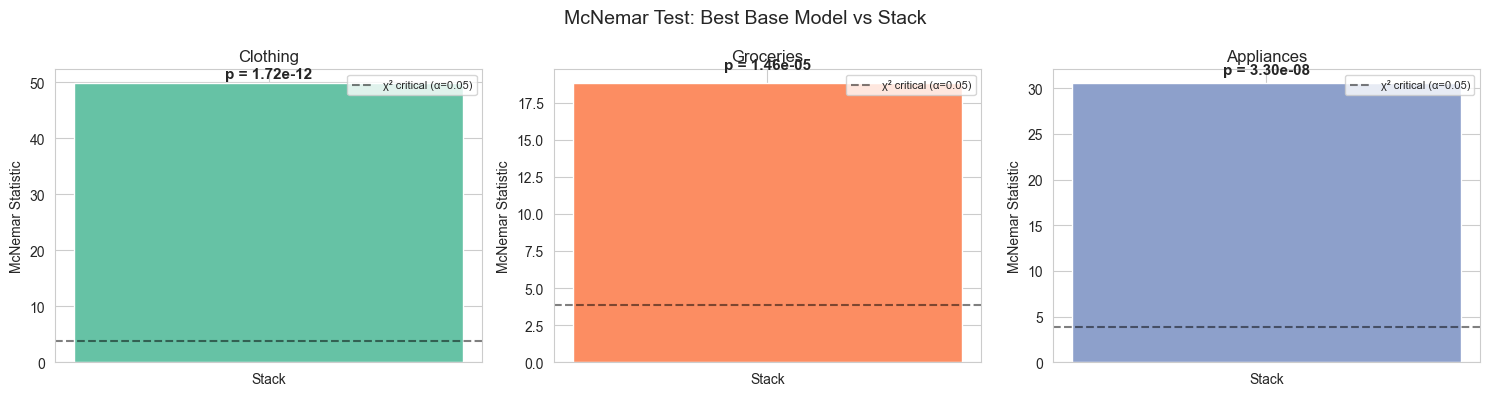

In [60]:
print('Plotting McNemar p-values...')
domains = list(mcnemar_results.keys())
pvals = [mcnemar_results[d]['p_value'] for d in domains]
stats = [mcnemar_results[d]['statistic'] for d in domains]
colors_mc = [sns.color_palette('Set2')[i] for i in range(len(domains))]

fig, axes = plt.subplots(1, len(domains), figsize=(5 * len(domains), 4))
if not isinstance(axes, np.ndarray):
    axes = [axes]
for i, (d, p, s) in enumerate(zip(domains, pvals, stats)):
    axes[i].bar(['Stack'], [s], color=colors_mc[i], width=0.5)
    axes[i].set_title(f'{d}')
    axes[i].set_ylabel('McNemar Statistic')
    axes[i].text(0, s + 1, f'p = {p}', ha='center', fontsize=11, fontweight='bold')
    axes[i].axhline(y=3.841, color='black', linestyle='--', alpha=0.5, label='χ² critical (α=0.05)')
    axes[i].legend(fontsize=8)
fig.suptitle('McNemar Test: Best Base Model vs Stack', fontsize=14)
plt.tight_layout()
plt.show()


## 18. ROC/AUC Curves (All 6 Models per Domain)


--- ROC/AUC: Clothing ---


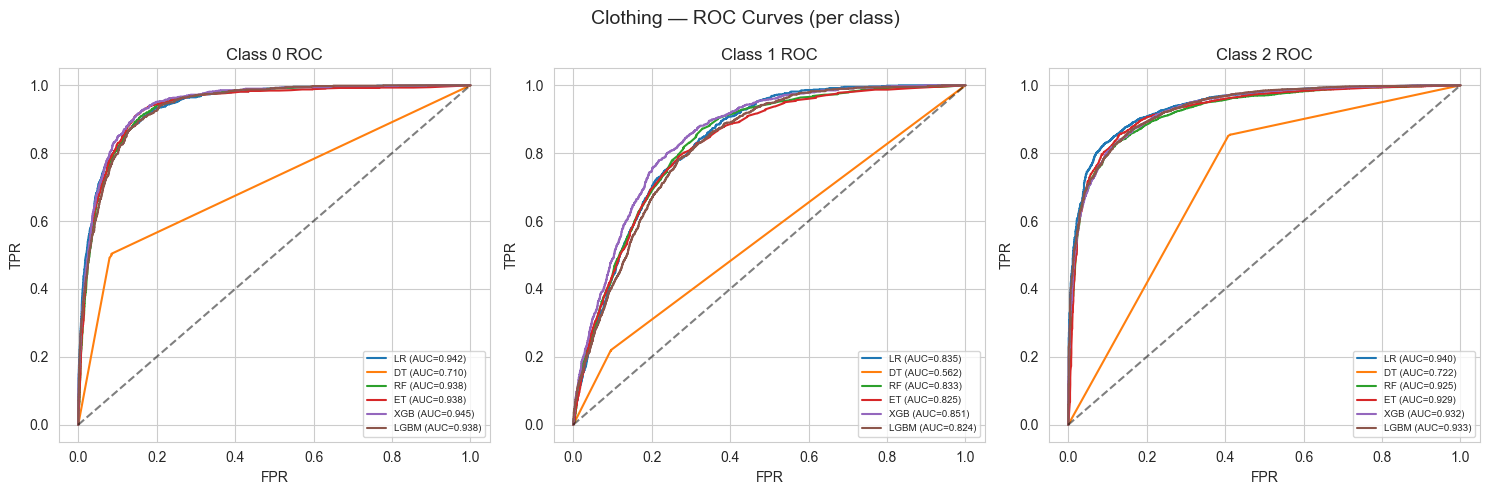


--- ROC/AUC: Groceries ---


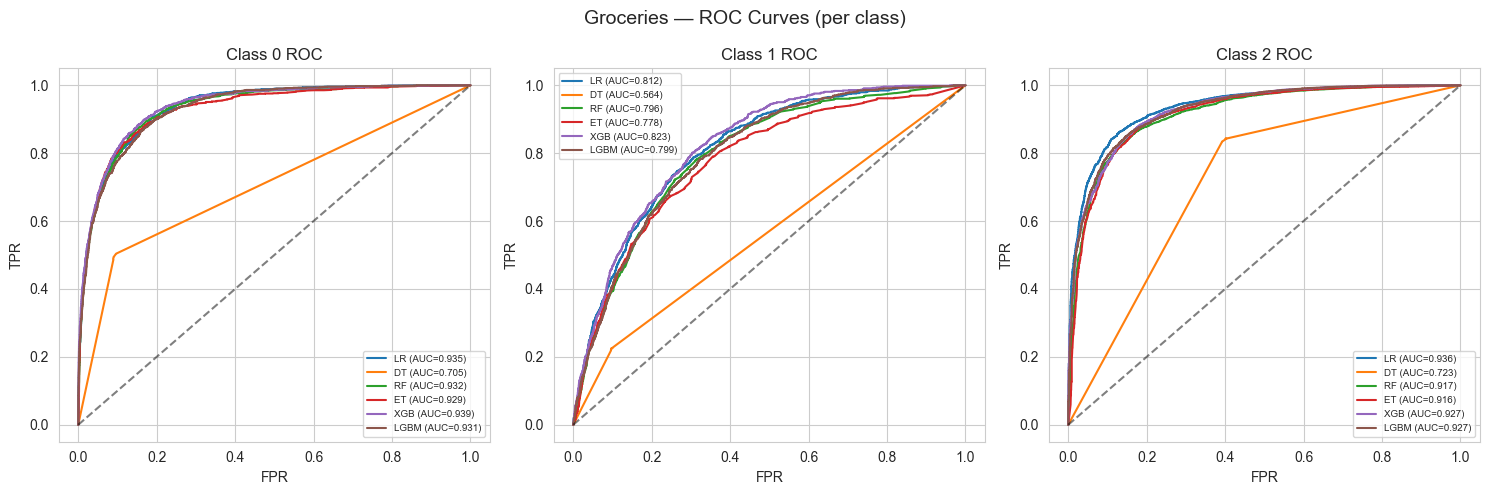


--- ROC/AUC: Appliances ---


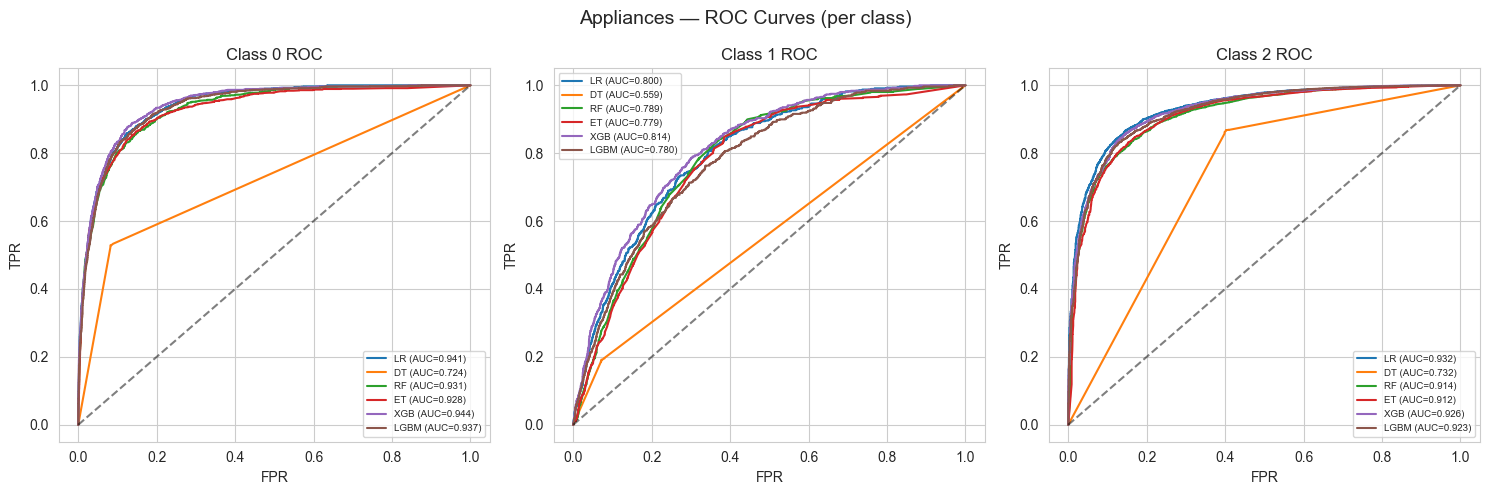

In [61]:
for domain_name in domain_dfs:
    print(f'\n--- ROC/AUC: {domain_name} ---')
    X_train, X_test, y_train, y_test = all_splits[domain_name]

    classes = np.unique(y_test)
    n_classes = len(classes)
    y_test_bin = label_binarize(y_test, classes=classes)

    fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5))
    if n_classes == 1:
        axes = [axes]

    for cls_idx in range(n_classes):
        ax = axes[cls_idx]
        for model_name in MODEL_NAMES:
            model = all_models[domain_name][model_name]
            if hasattr(model, 'predict_proba'):
                y_score = model.predict_proba(X_test)[:, cls_idx]
            else:
                # For models without predict_proba, use decision_function
                try:
                    y_score = model.decision_function(X_test)
                    if y_score.ndim > 1:
                        y_score = y_score[:, cls_idx]
                except AttributeError:
                    continue

            fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_score)
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax.set_title(f'Class {cls_idx} ROC')
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(fontsize=7)

    fig.suptitle(f'{domain_name} — ROC Curves (per class)', fontsize=14)
    plt.tight_layout()
    plt.show()

## 19. Summary

All 6 models have been trained and evaluated across 3 domains.
The stacking ensemble aggregates their predictions.
SHAP analysis provides both model-level and feature-level interpretability.
McNemar tests validate statistical significance of ensemble improvements.

In [62]:
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)
for domain_name in domain_dfs:
    print(f"\n{domain_name}:")
    display(final_tables[domain_name])

EXPERIMENT COMPLETE

Clothing:


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,XGB,84.845,0.5106,0.4906,0.4480,56.257
1,LR,84.384,0.5264,0.5171,0.6461,67.335
2,LGBM,83.795,0.5044,0.4971,0.6152,64.861
3,RF,79.770,0.3504,0.2684,0.1430,44.054
4,ET,79.599,0.3398,0.2562,0.1601,43.510
5,DT,77.708,0.3168,0.3131,0.4528,52.228
6,Stack,81.343,0.4051,0.3433,0.2539,47.357



Groceries:


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,LR,83.834,0.5488,0.5425,0.6362,66.656
1,XGB,83.759,0.5369,0.5169,0.4129,56.092
2,LGBM,82.813,0.5233,0.5161,0.6157,65.015
3,ET,80.018,0.4371,0.3688,0.2194,47.209
4,RF,79.567,0.4250,0.3530,0.1936,46.452
5,DT,76.303,0.3338,0.3314,0.4533,51.919
6,Stack,80.845,0.4456,0.4053,0.3020,49.076



Appliances:


,Model,Weighted F1-score,MCC,Cohen Kappa,G-Mean,Balanced Accuracy
0,XGB,85.507,0.5346,0.5112,0.3113,53.518
1,LR,85.148,0.5428,0.5325,0.6148,65.909
2,LGBM,84.541,0.5233,0.5141,0.5843,64.115
3,RF,82.221,0.4253,0.3452,0.1628,45.077
4,ET,81.262,0.3812,0.3011,0.1467,43.292
5,DT,79.850,0.3618,0.3587,0.4464,52.861
6,Stack,83.520,0.4654,0.4187,0.2161,48.290
